# Team pressure analysis (v31 - structured + clips)
Barca (team 0) vs Atletico (team 1) - Barca-Atletico first half

**Notebook map** (section numbers from earlier versions are kept; new sections use letters):

| Part | What it answers | Sections |
|---|---|---|
| **A. Setup & data contract** | where the tables live, schema check, orientation check | Setup, Setup-2 |
| **B. The pressure signal** | who presses the carrier, passing lanes, team-level events, stoppages | 0, 0b, 1, 2, 3, 4 |
| **C. WHERE - zone / channel / line / shape** | thirds (zone press), **left / centre / right**, **zone x channel grid**, defensive line (height, **left-right tilt**, by ball zone), compactness | 5, **5b**, 11, 6, 7, **6b**, 18 |
| **D. WHEN - speed of reaction** | time-to-press, counter-press fast / slow / never | 8, 8b, 9 |
| **E. EFFECT - what the press did** | passes under pressure, outcome taxonomy, PPDA, possessions, regain | 10, 12, 13, 14, 15, 15b |
| **F. TRIGGERS** | what invites a press | 16 |
| **G. Summaries** | team profile, diagnostics | 17, 19 |
| **H. Event registry + CLIPS** *(new)* | every metric above as a standard event table, auto-selected, annotated video clips + animated top-down view | **19b, 19c, 19d, 19e** |
| **I. Exports** | UI json, LLM json (now include channel / line / clip index) | 20, 21 |

Run top to bottom once; the clip section (H) can then be re-run on its own.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

FPS = 25
PITCH_LENGTH = 105
PITCH_WIDTH = 68
TEAM_NAMES = {0: "Barca", 1: "Atletico"}
ATTACK_SIGN = {0: 1.0, 1: -1.0}      # team 0 attacks +x, team 1 attacks -x (verified against attack_dir in Setup-2)

# ---------------- paths: single source of truth for this notebook ----------------
NEW_CACHE = Path(r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)"
                 r"\project\barca_atletico_first_half\new_cache")
PLAYER_PATH = NEW_CACHE / "player_frame_table_named.parquet"
BALL_PATH   = NEW_CACHE / "ball_frame_table_named.parquet"
VIDEO_PATH  = NEW_CACHE / "annotated_teams.mp4"
EXPORT_DIR  = NEW_CACHE / "pressure_analysis"      # json exports, clip index, stoppage check images
CLIPS_DIR   = EXPORT_DIR / "clips"
for _d in (EXPORT_DIR, CLIPS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

player_frame_table = pd.read_parquet(PLAYER_PATH)
ball_frame_table = pd.read_parquet(BALL_PATH)
print("player table:", PLAYER_PATH.name, player_frame_table.shape)
print("ball table  :", BALL_PATH.name, ball_frame_table.shape)


## Setup-2. Data contract
One place that checks the tables are what the rest of the notebook assumes (columns, dtypes, team orientation, fps) and derives what the named tables may call differently.

In [ ]:
# ===== Setup-2. Data contract: fix dtypes, derive missing columns, fail loudly on the rest =====
NEED_PLAYER = ["frame_idx", "track_id", "role", "team", "pitch_x", "pitch_y", "is_carrier"]
NEED_BALL   = ["frame_idx", "carrier_track_id", "carrier_team", "possession_team", "ball_pitch_x", "ball_pitch_y"]
NEED_CLIPS  = ["name", "number", "x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y"]   # only the clip section needs these

# --- ball table: accept the named-table spelling of the ball coordinates
_ren = {}
if "ball_pitch_x" not in ball_frame_table.columns and "pitch_x" in ball_frame_table.columns: _ren["pitch_x"] = "ball_pitch_x"
if "ball_pitch_y" not in ball_frame_table.columns and "pitch_y" in ball_frame_table.columns: _ren["pitch_y"] = "ball_pitch_y"
if _ren:
    ball_frame_table = ball_frame_table.rename(columns=_ren); print("ball table: renamed", _ren)

# --- player table first (needed to derive carrier_team)
for c in ["team"]:
    player_frame_table[c] = pd.to_numeric(player_frame_table[c], errors="coerce").astype("float64")
player_frame_table["is_carrier"] = player_frame_table["is_carrier"].fillna(False).astype(bool)
player_frame_table = player_frame_table.drop_duplicates(["frame_idx", "track_id"]).reset_index(drop=True)

if "carrier_team" not in ball_frame_table.columns and "carrier_track_id" in ball_frame_table.columns:
    _team_of = player_frame_table.dropna(subset=["team"]).groupby("track_id")["team"].agg(lambda s: s.mode().iat[0])
    ball_frame_table["carrier_team"] = ball_frame_table["carrier_track_id"].map(_team_of)
    print("ball table: derived carrier_team from carrier_track_id")
if "possession_team" not in ball_frame_table.columns and "carrier_team" in ball_frame_table.columns:
    ball_frame_table["possession_team"] = ball_frame_table["carrier_team"]
    print("WARNING: ball table has no possession_team - using carrier_team (no gap fill)")

for c in ["carrier_track_id", "carrier_team", "possession_team", "ball_pitch_x", "ball_pitch_y"]:
    if c in ball_frame_table.columns:
        ball_frame_table[c] = pd.to_numeric(ball_frame_table[c], errors="coerce").astype("float64")
ball_frame_table = ball_frame_table.drop_duplicates("frame_idx").sort_values("frame_idx").reset_index(drop=True)

_miss_p = [c for c in NEED_PLAYER if c not in player_frame_table.columns]
_miss_b = [c for c in NEED_BALL if c not in ball_frame_table.columns]
assert not _miss_p and not _miss_b, f"missing columns - player: {_miss_p} | ball: {_miss_b}"
_miss_c = [c for c in NEED_CLIPS if c not in player_frame_table.columns]
if _miss_c:
    print("NOTE: columns needed only for the clip section are missing:", _miss_c)

# --- orientation: every zone/line cell below hard-codes team 0 -> +x, team 1 -> -x
if "attack_dir" in player_frame_table.columns:
    _ad = (player_frame_table.dropna(subset=["team", "attack_dir"]).groupby("team")["attack_dir"].mean().apply(np.sign).to_dict())
    _ad = {int(k): float(v) for k, v in _ad.items()}
    assert _ad == ATTACK_SIGN, (f"attack_dir in the table says {_ad} but the notebook assumes {ATTACK_SIGN}; "
                                "zone / line / pass-progression cells would be mirrored for the other team")

# --- frame rate check
if "t_sec" in player_frame_table.columns:
    _fps = (player_frame_table.frame_idx.max() - player_frame_table.frame_idx.min()) / (player_frame_table.t_sec.max() - player_frame_table.t_sec.min())
    if abs(_fps - FPS) > 0.5: print(f"WARNING: table implies {_fps:.2f} fps but FPS={FPS}")

# --- identity helpers (named cache: one track_id = one shirt number + name)
def _mode(s):
    s = s.dropna(); return s.mode().iat[0] if len(s) else np.nan
_ti = player_frame_table.groupby("track_id").agg(role=("role", _mode), team=("team", _mode),
                                                  name=("name", _mode) if "name" in player_frame_table.columns else ("role", _mode),
                                                  number=("number", _mode) if "number" in player_frame_table.columns else ("team", _mode))
TRACK_ROLE = _ti["role"].to_dict(); TRACK_TEAM = _ti["team"].to_dict()
TRACK_LABEL = {int(i): (f"#{int(r.number)} {r['name']}" if "number" in player_frame_table.columns and pd.notna(r.number) else str(r["name"])) for i, r in _ti.iterrows()}
TRACK_NUM = {int(i): int(r.number) for i, r in _ti.iterrows() if "number" in player_frame_table.columns and pd.notna(r.number)}
GK_IDS = {int(i) for i, r in TRACK_ROLE.items() if r == "goalkeeper"}

print("\nroles:", player_frame_table["role"].value_counts(dropna=False).to_dict())
print(f"frames {player_frame_table.frame_idx.min()}..{player_frame_table.frame_idx.max()} | ball rows {len(ball_frame_table)} | "
      f"carrier coverage {ball_frame_table.carrier_track_id.notna().mean():.1%} | goalkeepers {sorted(GK_IDS)}")
print("data contract OK")


## 0. Team defensive baseline
Average depth of each team's back line (last-3 defenders), computed once up front, restricted to frames where that team is out of possession (their actual defending shape, not inflated by attacking-phase positioning). Used in section 1 to tell "stepped out to press" apart from "block was already sitting there".

In [2]:
LINE_HEIGHT_DEFENDERS_N = 3

_poss_for_baseline = ball_frame_table[["frame_idx", "possession_team"]]

_outfield_baseline = player_frame_table[player_frame_table["role"] == "player"].dropna(subset=["pitch_x", "pitch_y"]).copy()
_outfield_baseline = _outfield_baseline.merge(_poss_for_baseline, on="frame_idx", how="left")
_outfield_baseline = _outfield_baseline[
    _outfield_baseline["possession_team"].notna() &
    (_outfield_baseline["team"] != _outfield_baseline["possession_team"])
]  # keep only frames where this team is out of possession -- their real defensive shape

_outfield_baseline["dist_from_own_goal"] = np.where(
    _outfield_baseline["team"] == 0,
    _outfield_baseline["pitch_x"],
    PITCH_LENGTH - _outfield_baseline["pitch_x"]
)
_outfield_baseline["dist_from_own_goal"] = _outfield_baseline["dist_from_own_goal"].clip(0, PITCH_LENGTH)

team_defensive_line_avg = (
    _outfield_baseline.sort_values("dist_from_own_goal")
    .groupby(["frame_idx", "team"])
    .head(LINE_HEIGHT_DEFENDERS_N)
    .groupby("team")["dist_from_own_goal"]
    .mean()
    .to_dict()
)
print("team average defensive line depth, out-of-possession only (last-3 defenders, m from own goal):", team_defensive_line_avg)

team average defensive line depth, out-of-possession only (last-3 defenders, m from own goal): {0: 45.136470751647394, 1: 27.71720704266724}


## 0b. Stoppage detection
A no-carrier gap in `carrier_track_id` lasting >= `STOPPAGE_GAP_SEC` (10s) is flagged as a real stoppage (injury, goal, VAR check, cooling break) rather than ordinary loose-ball noise -- verified by eye against the video. `stoppage_frame_lookup` is a per-frame boolean used downstream (sections 4, 12, 14) so dead time doesn't get silently counted as live out-of-possession play.

In [3]:
STOPPAGE_GAP_SEC = 10.0
STOPPAGE_GAP_FRAMES = int(STOPPAGE_GAP_SEC * FPS)

carrier_missing = ball_frame_table[["frame_idx", "carrier_track_id"]].sort_values("frame_idx").reset_index(drop=True)
carrier_missing["is_missing"] = carrier_missing["carrier_track_id"].isna()
carrier_missing["gap_id"] = (carrier_missing["is_missing"] != carrier_missing["is_missing"].shift()).cumsum()

gap_runs = (
    carrier_missing[carrier_missing["is_missing"]]
    .groupby("gap_id")
    .agg(start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), n_frames=("frame_idx", "count"))
    .reset_index(drop=True)
)
gap_runs["duration_sec"] = gap_runs["n_frames"] / FPS

stoppages = gap_runs[gap_runs["duration_sec"] >= STOPPAGE_GAP_SEC].reset_index(drop=True)

# vectorized frame -> is_stoppage lookup
_stoppage_starts = stoppages["start_frame"].values
_stoppage_ends = stoppages["end_frame"].values

all_frames = ball_frame_table[["frame_idx"]].drop_duplicates().sort_values("frame_idx").reset_index(drop=True)
_frame_vals = all_frames["frame_idx"].values
_idx = np.searchsorted(_stoppage_starts, _frame_vals, side="right") - 1
_valid = _idx >= 0
_in_range = np.zeros(len(_frame_vals), dtype=bool)
_idx_valid = _idx[_valid]
_in_range[_valid] = _frame_vals[_valid] <= _stoppage_ends[_idx_valid]
all_frames["is_stoppage"] = _in_range

stoppage_frame_lookup = all_frames.set_index("frame_idx")["is_stoppage"]

print(f"{len(stoppages)} stoppages >= {STOPPAGE_GAP_SEC}s flagged, covering {stoppages['n_frames'].sum()} frames "
      f"({stoppages['duration_sec'].sum():.1f}s total dead time)")

26 stoppages >= 10.0s flagged, covering 11267 frames (450.7s total dead time)


## 1. Proximity pressure — distance from each off-ball defender to the ball carrier
A defender only counts as "pressuring" if they're close AND (a) they're closing the distance fast (actively running at the carrier, >=2.5 m/s), or (b) they're within touch-tight range (<1.5m) regardless of speed, or (c) they're clearly ahead of their team's own out-of-possession baseline line (stepped out of the block). This is meant to separate real pressing from a deep, compact block that's simply already sitting near the ball because the attacker walked into it. Thresholds tightened from the first pass -- 1.0 m/s and 2.0m were too permissive and let most of a passive block still count as "pressuring".

In [4]:
PRESSURE_DIST_THRESH_M = 5.0
CLOSING_WINDOW_FRAMES = 12       # ~0.5s @ 25fps, window used to measure closing speed
CLOSING_SPEED_THRESH_MPS = 2.5   # must be closing at least this fast to count as an active press from open play (walking pace was too permissive)
TIGHT_MARK_DIST_M = 1.5          # inside this range, counts as pressure even without active closing (touch-tight)
STEP_OUT_MARGIN_M = 4.0          # must be at least this far ahead of the team's own average line depth

carrier_pos = ball_frame_table[
    ["frame_idx", "carrier_track_id", "carrier_team", "possession_team", "ball_pitch_x", "ball_pitch_y"]
]

pft = player_frame_table.merge(carrier_pos, on="frame_idx", how="left")

off_ball = pft[
    (pft["role"] == "player") &
    pft["carrier_track_id"].notna() &
    (pft["track_id"] != pft["carrier_track_id"]) &
    (pft["team"] != pft["carrier_team"])
].copy()

off_ball["dist_to_carrier"] = (
    (off_ball["pitch_x"] - off_ball["ball_pitch_x"]) ** 2 +
    (off_ball["pitch_y"] - off_ball["ball_pitch_y"]) ** 2
) ** 0.5

off_ball_pressure = off_ball.dropna(subset=["dist_to_carrier"]).copy()
off_ball_pressure = off_ball_pressure.sort_values(["track_id", "frame_idx"]).reset_index(drop=True)

# closing speed: how fast dist_to_carrier has been shrinking over the last CLOSING_WINDOW_FRAMES for this player
off_ball_pressure["dist_to_carrier_prev"] = off_ball_pressure.groupby("track_id")["dist_to_carrier"].shift(CLOSING_WINDOW_FRAMES)
off_ball_pressure["frame_gap"] = off_ball_pressure["frame_idx"] - off_ball_pressure.groupby("track_id")["frame_idx"].shift(CLOSING_WINDOW_FRAMES)
off_ball_pressure["closing_speed_mps"] = np.where(
    (off_ball_pressure["frame_gap"] > 0) & (off_ball_pressure["frame_gap"] <= CLOSING_WINDOW_FRAMES * 2),
    (off_ball_pressure["dist_to_carrier_prev"] - off_ball_pressure["dist_to_carrier"]) / (off_ball_pressure["frame_gap"] / FPS),
    np.nan
)

# stepped ahead of the team's own habitual defensive line -> not just standing in the block
off_ball_pressure["dist_from_own_goal"] = np.where(
    off_ball_pressure["team"] == 0,
    off_ball_pressure["pitch_x"],
    PITCH_LENGTH - off_ball_pressure["pitch_x"]
)
off_ball_pressure["dist_from_own_goal"] = off_ball_pressure["dist_from_own_goal"].clip(0, PITCH_LENGTH)
off_ball_pressure["team_line_avg"] = off_ball_pressure["team"].map(team_defensive_line_avg)
off_ball_pressure["stepped_out_of_line"] = (
    off_ball_pressure["dist_from_own_goal"] >= off_ball_pressure["team_line_avg"] + STEP_OUT_MARGIN_M
)

off_ball_pressure["is_pressuring"] = (
    (off_ball_pressure["dist_to_carrier"] < PRESSURE_DIST_THRESH_M) &
    (
        (off_ball_pressure["dist_to_carrier"] < TIGHT_MARK_DIST_M) |
        (off_ball_pressure["closing_speed_mps"].fillna(0) >= CLOSING_SPEED_THRESH_MPS) |
        off_ball_pressure["stepped_out_of_line"]
    )
)

team_pressure_per_frame = (
    off_ball_pressure.groupby(["frame_idx", "team", "carrier_team", "possession_team"], as_index=False)
    .agg(
        n_pressing=("is_pressuring", "sum"),
        n_defenders_on_pitch=("track_id", "nunique"),
        min_dist_to_carrier=("dist_to_carrier", "min"),
    )
)
team_pressure_per_frame["pressing_intensity"] = (
    team_pressure_per_frame["n_pressing"] / team_pressure_per_frame["n_defenders_on_pitch"]
)

## 2. Passing-lane pressure — how covered are the carrier's passing options

In [5]:
MIN_LANE_LENGTH_M = 3.0
TIGHT_LANE_THRESH_M = 1.5
CONTESTED_LANE_THRESH_M = 3.0

carrier_frames = pft[(pft["role"] == "player") & pft["carrier_track_id"].notna()].copy()

teammates = carrier_frames[
    (carrier_frames["team"] == carrier_frames["carrier_team"]) &
    (carrier_frames["track_id"] != carrier_frames["carrier_track_id"])
]
opponents = carrier_frames[carrier_frames["team"] != carrier_frames["carrier_team"]]

carrier_player_pos = (
    player_frame_table[player_frame_table["is_carrier"] == True]
    [["frame_idx", "track_id", "pitch_x", "pitch_y"]]
    .rename(columns={"track_id": "carrier_track_id", "pitch_x": "carrier_x", "pitch_y": "carrier_y"})
    .drop_duplicates(subset="frame_idx", keep="first")
)

teammate_pos = teammates[["frame_idx", "track_id", "pitch_x", "pitch_y"]].rename(
    columns={"track_id": "teammate_id", "pitch_x": "tm_x", "pitch_y": "tm_y"}
)
opponent_pos = opponents[["frame_idx", "track_id", "pitch_x", "pitch_y"]].rename(
    columns={"track_id": "opponent_id", "pitch_x": "opp_x", "pitch_y": "opp_y"}
)

lanes = teammate_pos.merge(opponent_pos, on="frame_idx", how="inner")
lanes = lanes.merge(carrier_player_pos, on="frame_idx", how="inner")
lanes = lanes.dropna(subset=["carrier_x", "carrier_y"])

Ax, Ay = lanes["carrier_x"].values, lanes["carrier_y"].values
Bx, By = lanes["tm_x"].values, lanes["tm_y"].values
Px, Py = lanes["opp_x"].values, lanes["opp_y"].values

ABx, ABy = Bx - Ax, By - Ay
APx, APy = Px - Ax, Py - Ay

seg_len_sq = ABx ** 2 + ABy ** 2
seg_len_sq = np.where(seg_len_sq == 0, 1e-9, seg_len_sq)

t = (APx * ABx + APy * ABy) / seg_len_sq
t_clipped = np.clip(t, 0.0, 1.0)

closest_x = Ax + t_clipped * ABx
closest_y = Ay + t_clipped * ABy
perp_dist = np.sqrt((Px - closest_x) ** 2 + (Py - closest_y) ** 2)

lanes["t"] = t
lanes["lane_perp_dist"] = perp_dist
lanes["lane_length_m"] = np.sqrt(seg_len_sq)

valid_lanes = lanes[
    (lanes["lane_length_m"] >= MIN_LANE_LENGTH_M) &
    (lanes["t"] >= 0.15) &
    (lanes["t"] <= 0.85)
].copy()

valid_lanes["lane_tight_block"] = valid_lanes["lane_perp_dist"] < TIGHT_LANE_THRESH_M
valid_lanes["lane_contested"] = valid_lanes["lane_perp_dist"] < CONTESTED_LANE_THRESH_M

lane_status = (
    valid_lanes.groupby(["frame_idx", "teammate_id"], as_index=False)
    .agg(lane_tight_block=("lane_tight_block", "any"), lane_contested=("lane_contested", "any"))
)

frame_lane_summary = (
    lane_status.groupby("frame_idx", as_index=False)
    .agg(
        n_lanes_total=("teammate_id", "nunique"),
        n_lanes_tight_blocked=("lane_tight_block", "sum"),
        n_lanes_contested=("lane_contested", "sum"),
    )
)
frame_lane_summary["n_lanes_open"] = frame_lane_summary["n_lanes_total"] - frame_lane_summary["n_lanes_contested"]
frame_lane_summary["frac_tight_blocked"] = frame_lane_summary["n_lanes_tight_blocked"] / frame_lane_summary["n_lanes_total"]
frame_lane_summary["frac_contested"] = frame_lane_summary["n_lanes_contested"] / frame_lane_summary["n_lanes_total"]

frame_lane_summary = frame_lane_summary.merge(
    carrier_pos[["frame_idx", "carrier_team", "possession_team"]], on="frame_idx", how="left"
)


## 3. Unified team pressure signal + events
Combines proximity pressure OR lane-blocking pressure, then excludes own-penalty-box frames (16.5m from own goal) since compact box defending is a different phenomenon from active pressing. This corrected `under_team_pressure` definition is used everywhere downstream (events, zone breakdown, time-to-press, pass resistance, weighted intensity).
Note: `n_pressing`/`pressing_intensity` now come from the closing-speed + step-out-of-line gated definition in section 1, not raw distance -- so a passive deep block no longer inflates this on its own. The lane-blocking signal (section 2) is left distance-based for now, since being within `TIGHT_LANE_THRESH_M` of an actual pass lane is a real obstruction regardless of how the defender got there.

In [6]:
N_PRESSING_THRESH = 2
FRAC_TIGHT_BLOCKED_THRESH = 0.375
MIN_EVENT_DURATION_SEC = 0.5
GAP_TOLERANCE_FRAMES = 5
BOX_DEPTH_M = 16.5

team_pressure_full = team_pressure_per_frame.merge(
    frame_lane_summary[["frame_idx", "n_lanes_total", "n_lanes_tight_blocked",
                         "n_lanes_contested", "frac_tight_blocked", "frac_contested"]],
    on="frame_idx",
    how="left"
)

ball_pos_by_frame = ball_frame_table[["frame_idx", "ball_pitch_x", "ball_pitch_y"]].rename(
    columns={"ball_pitch_x": "press_x", "ball_pitch_y": "press_y"}
)
team_pressure_full = team_pressure_full.merge(ball_pos_by_frame, on="frame_idx", how="left")

tpf = team_pressure_full.copy()
tpf["frac_tight_blocked"] = tpf["frac_tight_blocked"].fillna(0)

tpf["in_own_box"] = np.where(
    tpf["team"] == 0,
    tpf["press_x"] <= BOX_DEPTH_M,
    tpf["press_x"] >= PITCH_LENGTH - BOX_DEPTH_M
)

tpf["under_team_pressure"] = (
    ((tpf["n_pressing"] >= N_PRESSING_THRESH) | (tpf["frac_tight_blocked"] >= FRAC_TIGHT_BLOCKED_THRESH)) &
    (~tpf["in_own_box"])
)

# carry the corrected flag back onto team_pressure_full so every downstream section uses the same definition
team_pressure_full["under_team_pressure"] = tpf["under_team_pressure"]

tpf = tpf.sort_values(["team", "frame_idx"]).reset_index(drop=True)

events_list = []
for team_id, grp in tpf.groupby("team"):
    grp = grp.sort_values("frame_idx").reset_index(drop=True)

    is_press = grp["under_team_pressure"].values.copy()
    frames = grp["frame_idx"].values
    i, n = 0, len(is_press)
    while i < n:
        if not is_press[i]:
            j = i
            while j < n and not is_press[j]:
                j += 1
            gap_frame_span = frames[j - 1] - frames[i] + 1 if j > i else 0
            if i > 0 and j < n and gap_frame_span <= GAP_TOLERANCE_FRAMES:
                is_press[i:j] = True
            i = j
        else:
            i += 1
    grp["under_team_pressure_bridged"] = is_press

    grp["state_change"] = (grp["under_team_pressure_bridged"] != grp["under_team_pressure_bridged"].shift()).cumsum()
    runs = (
        grp.groupby("state_change")
        .agg(
            start_frame=("frame_idx", "first"),
            end_frame=("frame_idx", "last"),
            n_frames=("frame_idx", "count"),
            under_pressure=("under_team_pressure_bridged", "first"),
            possession_team=("possession_team", "first"),
            mean_n_pressing=("n_pressing", "mean"),
            mean_frac_tight_blocked=("frac_tight_blocked", "mean"),
        )
        .reset_index(drop=True)
    )
    runs["team"] = team_id
    events_list.append(runs)

team_pressure_events = pd.concat(events_list, ignore_index=True)
team_pressure_events = team_pressure_events[team_pressure_events["under_pressure"]].copy()
team_pressure_events["duration_sec"] = team_pressure_events["n_frames"] / FPS
team_pressure_events = team_pressure_events[
    team_pressure_events["duration_sec"] >= MIN_EVENT_DURATION_SEC
].reset_index(drop=True)

print("total team pressure events:", len(team_pressure_events))
print(team_pressure_events.groupby("team")["duration_sec"].describe())


total team pressure events: 249
      count      mean       std   min   25%   50%   75%   max
team                                                         
0     105.0  1.612952  1.532163  0.52  0.68  1.08  1.88  9.12
1     144.0  1.362778  0.898766  0.52  0.76  1.12  1.60  5.60


## 4. Total pressure time, normalized by each team's out-of-possession window

In [7]:
total_pressure_frames_by_team = team_pressure_events.groupby("team")["n_frames"].sum()
total_pressure_seconds_by_team = total_pressure_frames_by_team / FPS

bft_live = ball_frame_table.merge(stoppage_frame_lookup.rename("is_stoppage"), left_on="frame_idx", right_index=True, how="left")
bft_live["is_stoppage"] = bft_live["is_stoppage"].fillna(False)
bft_live = bft_live[~bft_live["is_stoppage"]]  # dead time isn't real out-of-possession play, exclude it

possession_frames_by_team = bft_live["possession_team"].value_counts(dropna=True)
total_labeled_frames = bft_live["possession_team"].notna().sum()
out_of_possession_frames = {
    0: total_labeled_frames - possession_frames_by_team.get(0, 0),
    1: total_labeled_frames - possession_frames_by_team.get(1, 0),
}
out_of_possession_seconds = {k: v / FPS for k, v in out_of_possession_frames.items()}

match_duration_sec = (player_frame_table["frame_idx"].max() + 1) / FPS

print("total pressure seconds by team:\n", total_pressure_seconds_by_team)
print(f"\nmatch duration: {match_duration_sec:.1f}s ({stoppages['duration_sec'].sum():.1f}s of that is stoppage time, excluded below)")
for team_id in [0, 1]:
    pct = total_pressure_seconds_by_team.get(team_id, 0) / out_of_possession_seconds[team_id] * 100
    print(f"team {team_id}: {total_pressure_seconds_by_team.get(team_id, 0):.1f}s pressing / "
          f"{out_of_possession_seconds[team_id]:.1f}s out of possession = {pct:.1f}% pressing intensity")

total pressure seconds by team:
 team
0    169.36
1    196.24
Name: n_frames, dtype: float64

match duration: 2813.0s (450.7s of that is stoppage time, excluded below)
team 0: 169.4s pressing / 721.9s out of possession = 23.5% pressing intensity
team 1: 196.2s pressing / 1072.5s out of possession = 18.3% pressing intensity


## 5. Pressure by pitch zone (own / middle / attacking third, relative to pressing team's attack direction)
Uses the corrected `under_team_pressure` from section 3 (already excludes own-box frames).

In [8]:
tpf_zone = team_pressure_full.copy()

def classify_zone(row):
    x = row["press_x"]
    if pd.isna(x):
        return None
    if row["team"] == 0:
        if x < 35: return "own_third"
        elif x < 70: return "middle_third"
        else: return "attacking_third"
    else:
        if x > 70: return "own_third"
        elif x > 35: return "middle_third"
        else: return "attacking_third"

tpf_zone["press_zone"] = tpf_zone.apply(classify_zone, axis=1)

pressing_only = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna()]

zone_counts = pressing_only.groupby(["team", "press_zone"]).size().unstack(fill_value=0)
zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100

print("pressure frames by team and zone:\n", zone_counts)
print("\n% distribution within each team's own pressing:\n", zone_pct)


pressure frames by team and zone:
 press_zone  attacking_third  middle_third  own_third
team                                                
0                      2029          1558        736
1                       530          2814       1980

% distribution within each team's own pressing:
 press_zone  attacking_third  middle_third  own_third
team                                                
0                 46.934999     36.039787  17.025214
1                  9.954921     52.854996  37.190083


## 5b. Pressure by channel (left / centre / right) and the zone x channel grid
Section 5 only splits pressure by **third**. This adds the lateral split, so "where a team presses" becomes a 3 x 3 grid (own / middle / attacking third x left / centre / right). Channels are measured from the **pressing team's own attacking direction** (left = the pressing team's left when it faces the opposition goal), same convention as the zones. If left/right come out mirrored against what you see on video, set `FLIP_CHANNELS = True`.


In [ ]:
FLIP_CHANNELS = False
CHANNEL_ORDER = ["left", "centre", "right"]
ZONE_ORDER_5 = ["own_third", "middle_third", "attacking_third"]

def zone_for_team(x, team):
    # thirds relative to `team`'s own attack direction (same definition as section 13; defined here because sections 5b / 6b use it first)
    if pd.isna(x):
        return None
    if team == 0:
        return "own_third" if x < 35 else ("middle_third" if x < 70 else "attacking_third")
    return "own_third" if x > 70 else ("middle_third" if x > 35 else "attacking_third")

def channel_for_team(y, team):
    # 180-degree rotation for team 1 (x and y both flip), so left/right stay in the pressing team's own frame
    if pd.isna(y):
        return None
    y_att = y if int(team) == 0 else PITCH_WIDTH - y
    ch = "left" if y_att < PITCH_WIDTH / 3 else ("right" if y_att > 2 * PITCH_WIDTH / 3 else "centre")
    if FLIP_CHANNELS:
        ch = {"left": "right", "right": "left"}.get(ch, ch)
    return ch

tpf_zone["press_channel"] = [channel_for_team(y, t) for y, t in zip(tpf_zone["press_y"], tpf_zone["team"])]

pressing_zc = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna() & tpf_zone["press_channel"].notna()]

channel_counts = (pressing_zc.groupby(["team", "press_channel"]).size().unstack(fill_value=0)
                  .reindex(columns=CHANNEL_ORDER, fill_value=0))
channel_pct = channel_counts.div(channel_counts.sum(axis=1), axis=0) * 100

zone_channel_counts = (pressing_zc.groupby(["team", "press_zone", "press_channel"]).size().unstack(fill_value=0)
                       .reindex(columns=CHANNEL_ORDER, fill_value=0)
                       .reindex(pd.MultiIndex.from_product([[0, 1], ZONE_ORDER_5], names=["team", "press_zone"]), fill_value=0))
zone_channel_pct = zone_channel_counts.copy().astype(float)
for _t in [0, 1]:
    _tot = zone_channel_counts.loc[_t].values.sum()
    zone_channel_pct.loc[_t] = zone_channel_counts.loc[_t] / _tot * 100 if _tot else 0.0

print("pressure frames by team and channel (pressing team's own left/right):\n", channel_counts)
print("\n% within each team's own pressing:\n", channel_pct.round(1))
print("\nzone x channel, % of the team's pressure frames:\n", zone_channel_pct.round(1))

# 3 x 3 grids, drawn in each pressing team's own frame (own goal on the left, left channel at the top)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, team_id, cmap in zip(axes, [0, 1], ["Greens", "Purples"]):
    grid = zone_channel_pct.loc[team_id].reindex(ZONE_ORDER_5).T.reindex(CHANNEL_ORDER)       # rows = channel, cols = zone
    ax.imshow(grid.values, cmap=cmap, aspect="auto", vmin=0, vmax=max(grid.values.max(), 1))
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{grid.values[i, j]:.1f}%", ha="center", va="center", fontsize=13, weight="bold")
    ax.set_xticks(range(3)); ax.set_xticklabels(["own third", "middle third", "attacking third"])
    ax.set_yticks(range(3)); ax.set_yticklabels(CHANNEL_ORDER)
    ax.set_title(f"{TEAM_NAMES[team_id]} - where it presses (% of its pressure frames)\n-> pressing team attacks to the right", fontsize=11)
plt.tight_layout(); plt.show()


## 6. Defensive line height (distance from own goal, last-1 and last-3 defenders)

In [9]:
BOUNDS_TOLERANCE_M = 2.0

outfield = player_frame_table[player_frame_table["role"] == "player"].copy()
outfield = outfield.dropna(subset=["pitch_x", "pitch_y"])

in_bounds = (
    (outfield["pitch_x"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (outfield["pitch_y"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
)
outfield = outfield[in_bounds].copy()

outfield["dist_from_own_goal"] = np.where(
    outfield["team"] == 0,
    outfield["pitch_x"],
    PITCH_LENGTH - outfield["pitch_x"]
)
outfield["dist_from_own_goal"] = outfield["dist_from_own_goal"].clip(0, PITCH_LENGTH)

def compute_line_height(df, n_defenders):
    return (
        df.sort_values("dist_from_own_goal")
        .groupby(["frame_idx", "team"])
        .head(n_defenders)
        .groupby(["frame_idx", "team"], as_index=False)["dist_from_own_goal"]
        .mean()
        .rename(columns={"dist_from_own_goal": "line_height_m"})
    )

def remove_outliers_iqr(df, col, group_cols):
    parts = []
    for _, g in df.groupby(group_cols):
        q1, q3 = g[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        parts.append(g[(g[col] >= lo) & (g[col] <= hi)])
    return pd.concat(parts, ignore_index=True)

poss = ball_frame_table[["frame_idx", "possession_team"]]

line_last1 = compute_line_height(outfield, 1).merge(poss, on="frame_idx", how="left")
line_last3 = compute_line_height(outfield, 3).merge(poss, on="frame_idx", how="left")

line_last1_clean = remove_outliers_iqr(line_last1, "line_height_m", ["team"])
line_last3_clean = remove_outliers_iqr(line_last3, "line_height_m", ["team"])

avg_line_height = line_last3_clean.groupby("team")["line_height_m"].mean()

print("last-1 defender:\n", line_last1_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))
print("\nlast-3 defenders avg:\n", line_last3_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))


last-1 defender:
            mean     median        std
team                                 
0     44.577749  49.330734  19.090735
1     26.230183  22.755009  17.660295

last-3 defenders avg:
            mean     median        std
team                                 
0     47.792956  51.421569  19.834561
1     28.633750  24.759707  18.139512


## 7. Defensive line height — pitch visualization

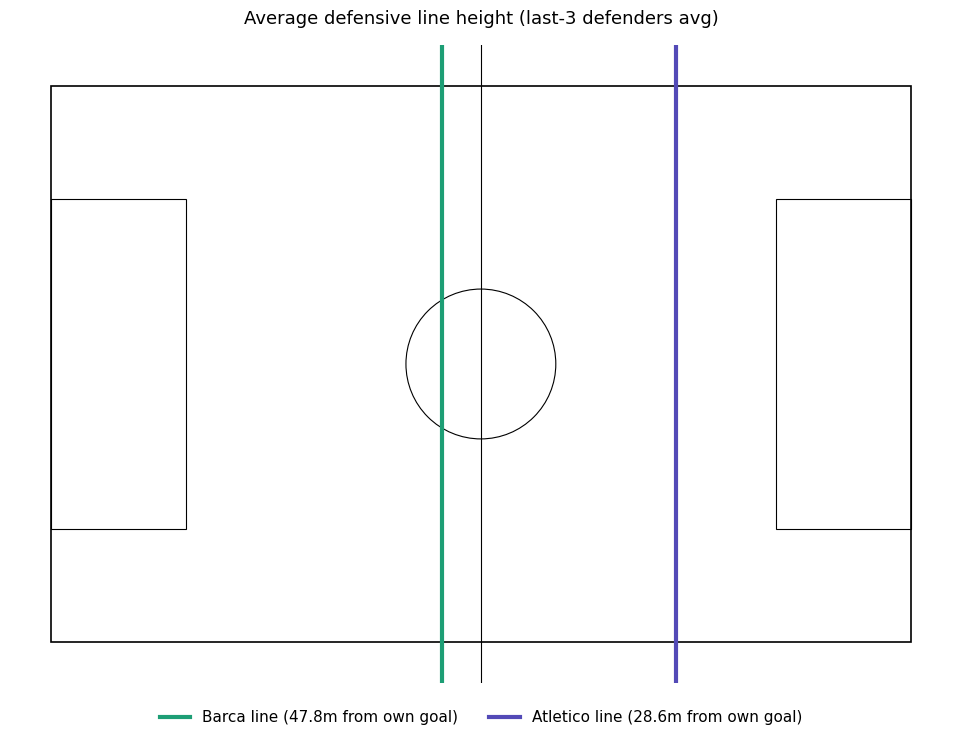

In [10]:
team0_line_x = avg_line_height[0]
team1_line_x = PITCH_LENGTH - avg_line_height[1]

fig, ax = plt.subplots(figsize=(12, 7.5))

ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.8)
ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.8))

box_depth, box_width = 16.5, 40.3
ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))
ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))

ax.axvline(team0_line_x, color="#1D9E75", linewidth=3, label=f"Barca line ({team0_line_x:.1f}m from own goal)")
ax.axvline(team1_line_x, color="#534AB7", linewidth=3, label=f"Atletico line ({avg_line_height[1]:.1f}m from own goal)")

ax.set_xlim(-5, PITCH_LENGTH + 5)
ax.set_ylim(-5, PITCH_WIDTH + 5)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=11)
ax.set_title("Average defensive line height (last-3 defenders avg)", fontsize=13, pad=15)

plt.tight_layout()
plt.show()


## 6b. Defensive line structure - height, left-right tilt, by ball zone, and line events
Section 6 gives one average line height per team. This keeps the **per-frame line state** (out-of-possession frames only) so the line can be broken down and clipped:

- `line_last1_m` / `line_last3_m` - height of the deepest defender / average of the deepest three (m from own goal).
- `line_tilt_m` - **left-right tilt**: mean height of the back-4 players on the left half minus the right half (positive = left side of the line is higher). Shows whether the line leans toward the ball side.
- `line_by_ball_zone` / `line_by_ball_channel` - how the line behaves when the ball is in each third / each channel.
- `defensive_line_events` - sustained **high line**, sustained **deep line** (team's own 80th / 20th percentile, >= `MIN_LINE_EVENT_SEC`) and **line step-ups** (line rises >= `LINE_STEP_UP_M` within `LINE_STEP_UP_WINDOW_SEC`).


In [ ]:
BACK_N_TILT = 4
HIGH_LINE_PCTL, DEEP_LINE_PCTL = 80, 20
MIN_LINE_EVENT_SEC = 3.0
LINE_STEP_UP_M, LINE_STEP_UP_WINDOW_SEC = 8.0, 2.0

def _mask_runs(frames, mask, max_gap=5, min_len=1):
    # contiguous True-runs of `mask` over `frames` (sorted frame numbers); gaps up to max_gap frames are bridged
    frames = np.asarray(frames); idx = np.flatnonzero(np.asarray(mask, bool))
    if len(idx) == 0:
        return []
    runs, s, p = [], idx[0], idx[0]
    for i in idx[1:]:
        if frames[i] - frames[p] > max_gap + 1:
            runs.append((int(frames[s]), int(frames[p]))); s = i
        p = i
    runs.append((int(frames[s]), int(frames[p])))
    return [(a, b) for a, b in runs if b - a + 1 >= min_len]

_ls = outfield.merge(poss, on="frame_idx", how="left")
_ls = _ls[_ls["possession_team"].notna() & (_ls["team"] != _ls["possession_team"])].copy()      # defending frames only
_ls["y_att"] = np.where(_ls["team"] == 0, _ls["pitch_y"], PITCH_WIDTH - _ls["pitch_y"])
if FLIP_CHANNELS:
    _ls["y_att"] = PITCH_WIDTH - _ls["y_att"]
_ls = _ls.sort_values(["frame_idx", "team", "dist_from_own_goal"])
_ls["rank_back"] = _ls.groupby(["frame_idx", "team"]).cumcount()
_back = _ls[_ls["rank_back"] < BACK_N_TILT]
_key = ["frame_idx", "team"]

line_state = pd.concat({
    "line_last1_m": _back[_back["rank_back"] == 0].set_index(_key)["dist_from_own_goal"],
    "line_last3_m": _back[_back["rank_back"] < 3].groupby(_key)["dist_from_own_goal"].mean(),
    "_left": _back[_back["y_att"] < PITCH_WIDTH / 2].groupby(_key)["dist_from_own_goal"].mean(),
    "_right": _back[_back["y_att"] >= PITCH_WIDTH / 2].groupby(_key)["dist_from_own_goal"].mean(),
    "line_width_m": _back.groupby(_key)["y_att"].agg(lambda s: s.max() - s.min()),
    "n_back": _back.groupby(_key).size(),
}, axis=1).reset_index()
line_state["line_tilt_m"] = line_state["_left"] - line_state["_right"]
line_state = line_state.drop(columns=["_left", "_right"]).dropna(subset=["line_last3_m"])
line_state = line_state[line_state["n_back"] >= 3].merge(ball_pos_by_frame.rename(columns={"press_x": "ball_x", "press_y": "ball_y"}), on="frame_idx", how="left")

line_state["ball_zone"] = [zone_for_team(x, t) if pd.notna(x) else None for x, t in zip(line_state["ball_x"], line_state["team"])]
line_state["ball_channel"] = [channel_for_team(y, t) if pd.notna(y) else None for y, t in zip(line_state["ball_y"], line_state["team"])]

line_by_ball_zone = (line_state.groupby(["team", "ball_zone"])["line_last3_m"].agg(["mean", "median", "count"]).round(1))
line_by_ball_channel = (line_state.groupby(["team", "ball_channel"]).agg(line_last3_m=("line_last3_m", "mean"), tilt_m=("line_tilt_m", "mean"), n=("line_tilt_m", "size")).round(2))
print("defensive line (last-3, m from own goal) by where the ball is, relative to the DEFENDING team:\n", line_by_ball_zone)
print("\nline height and left-right tilt (+ = left side higher) by ball channel:\n", line_by_ball_channel)

# ---- line events
_ev = []
for _t, _g in line_state.groupby("team"):
    _g = _g.sort_values("frame_idx"); fr_ = _g["frame_idx"].values; h = _g["line_last3_m"].values
    hi, lo = np.percentile(h, HIGH_LINE_PCTL), np.percentile(h, DEEP_LINE_PCTL)
    for sub, mask in [("high_line", h >= hi), ("deep_line", h <= lo)]:
        for a, b in _mask_runs(fr_, mask, max_gap=5, min_len=int(MIN_LINE_EVENT_SEC * FPS)):
            seg = _g[(_g["frame_idx"] >= a) & (_g["frame_idx"] <= b)]
            _ev.append(dict(team=int(_t), subtype=sub, start_frame=a, end_frame=b, mean_line_m=seg["line_last3_m"].mean(),
                            peak_line_m=seg["line_last3_m"].max() if sub == "high_line" else seg["line_last3_m"].min(), rise_m=np.nan))
    # step-ups: height now minus height `window` frames ago (only where both frames are defending frames)
    s_ = pd.Series(h, index=fr_); win = int(LINE_STEP_UP_WINDOW_SEC * FPS)
    prev = s_.reindex(fr_ - win).values
    rise = h - prev
    for a, b in _mask_runs(fr_, np.nan_to_num(rise, nan=0) >= LINE_STEP_UP_M, max_gap=10, min_len=1):
        seg = _g[(_g["frame_idx"] >= a) & (_g["frame_idx"] <= b)]
        _ev.append(dict(team=int(_t), subtype="line_step_up", start_frame=a - win, end_frame=b, mean_line_m=seg["line_last3_m"].mean(),
                        peak_line_m=seg["line_last3_m"].max(), rise_m=float(np.nanmax(rise[(fr_ >= a) & (fr_ <= b)]))))
defensive_line_events = pd.DataFrame(_ev)
if len(defensive_line_events):
    defensive_line_events["duration_sec"] = (defensive_line_events["end_frame"] - defensive_line_events["start_frame"] + 1) / FPS
    print("\ndefensive-line events:\n", defensive_line_events.groupby(["team", "subtype"]).size().unstack(fill_value=0))
else:
    print("\nno defensive-line events found (check thresholds)")

fig, ax = plt.subplots(figsize=(13, 3.6))
for t, colr in [(0, "#1D9E75"), (1, "#534AB7")]:
    g = line_state[line_state["team"] == t].sort_values("frame_idx")
    ax.plot(g["frame_idx"] / FPS / 60, g["line_last3_m"].rolling(FPS * 8, min_periods=10).mean(), c=colr, lw=1.4, label=TEAM_NAMES[t])
ax.set_xlabel("match minute"); ax.set_ylabel("line height (m from own goal)"); ax.set_title("Defensive line height (last-3), 8 s rolling mean, defending frames only")
ax.legend(); plt.tight_layout(); plt.show()


## 8. Time-to-press after losing the ball
Turnovers derived from raw (unsmoothed) carrier-team changes, filtered to stable holds (>=1.5s) to exclude 50/50 scramble noise.

In [11]:
MIN_HOLD_SEC = 1.5
MIN_HOLD_FRAMES = int(MIN_HOLD_SEC * FPS)
MAX_SEARCH_WINDOW_SEC = 10
MAX_SEARCH_WINDOW_FRAMES = MAX_SEARCH_WINDOW_SEC * FPS

raw_carrier = ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]].sort_values("frame_idx").reset_index(drop=True)
raw_carrier["state_change"] = (raw_carrier["carrier_team"] != raw_carrier["carrier_team"].shift()).cumsum()
carrier_runs = (
    raw_carrier.groupby("state_change")
    .agg(start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), n_frames=("frame_idx", "count"), carrier_team=("carrier_team", "first"))
    .reset_index(drop=True)
)

stable_runs = carrier_runs[carrier_runs["n_frames"] >= MIN_HOLD_FRAMES].reset_index(drop=True)

turnovers = []
for i in range(len(stable_runs) - 1):
    losing_team = stable_runs.loc[i, "carrier_team"]
    gaining_team = stable_runs.loc[i + 1, "carrier_team"]
    if losing_team != gaining_team:
        turnovers.append({"losing_team": losing_team, "loss_frame": stable_runs.loc[i, "end_frame"]})
turnovers = pd.DataFrame(turnovers)

press_lookup = team_pressure_full[["frame_idx", "team", "under_team_pressure"]].copy()

results = []
for _, row in turnovers.iterrows():
    team_id = row["losing_team"]
    loss_frame = row["loss_frame"]
    window = press_lookup[
        (press_lookup["team"] == team_id) &
        (press_lookup["frame_idx"] >= loss_frame) &
        (press_lookup["frame_idx"] <= loss_frame + MAX_SEARCH_WINDOW_FRAMES) &
        (press_lookup["under_team_pressure"])
    ]
    if len(window) > 0:
        first_press_frame = window["frame_idx"].min()
        results.append({"team": team_id, "loss_frame": loss_frame, "time_to_press_sec": (first_press_frame - loss_frame) / FPS})

time_to_press = pd.DataFrame(results)

print("genuine turnover events:", len(turnovers))
print(f"turnovers with a press detected within {MAX_SEARCH_WINDOW_SEC}s: {len(time_to_press)} / {len(turnovers)}")
print("\ntime-to-press stats by team (seconds):")
print(time_to_press.groupby("team")["time_to_press_sec"].agg(["mean", "median", "min", "max", "count"]))


genuine turnover events: 110
turnovers with a press detected within 10s: 86 / 110

time-to-press stats by team (seconds):
          mean  median   min   max  count
team                                     
0     3.290435    3.36  0.04  9.92     46
1     4.127000    3.60  0.04  9.96     40


## 8b. Counter-press effectiveness -- time-to-press by response speed
Extends section 8: does responding fast to losing the ball actually predict winning it back, or is that just what pressure volume looks like anyway? Turnovers are re-anchored on the opponent's *confirmed* takeover frame (the fix below), not the losing team's own last touch -- anchoring on the losing team's own frame trivially matched `losing_team` in the regain window every time, which is what the corrected version fixes. `time_to_press_sec` (from section 8) is then bucketed into fast (pressed within `COUNTER_PRESS_WINDOW_SEC`) / slow (pressed later, within section 8's `MAX_SEARCH_WINDOW_SEC`) / never.

In [12]:
## Counter-press effectiveness — corrected anchor point
## Bug in prior version: loss_frame is the LAST frame of the losing team's own run, so the window's
## own starting frame trivially matched losing_team every time (100% regain rate for both teams was
## the tell). Fixed by anchoring on the confirmed start of the opponent's next stable run instead.

COUNTER_PRESS_WINDOW_SEC = 5.0
COUNTER_PRESS_WINDOW_FRAMES = int(COUNTER_PRESS_WINDOW_SEC * FPS)

# local carrier lookup -- kept separate from section 14's _carrier_frame_idx/_carrier_team_vals
# (same underlying data, different variable names) so this section runs standalone regardless
# of where it sits relative to section 14
_cp_carrier_lookup = (
    ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]]
    .sort_values("frame_idx")
)
_cp_carrier_frame_idx = _cp_carrier_lookup["frame_idx"].values
_cp_carrier_team_vals = _cp_carrier_lookup["carrier_team"].values

# rebuild turnovers with the opponent's confirmed start frame included
turnovers_fixed = []
for i in range(len(stable_runs) - 1):
    losing_team = stable_runs.loc[i, "carrier_team"]
    gaining_team = stable_runs.loc[i + 1, "carrier_team"]
    if losing_team != gaining_team:
        turnovers_fixed.append({
            "losing_team": losing_team,
            "loss_frame": stable_runs.loc[i, "end_frame"],
            "gain_frame": stable_runs.loc[i + 1, "start_frame"],  # opponent's confirmed takeover, the real turnover boundary
        })
turnovers_fixed = pd.DataFrame(turnovers_fixed)

def regained_after_turnover(losing_team, gain_frame):
    # search strictly AFTER the opponent's takeover frame, not from the losing team's own last touch
    lo = np.searchsorted(_cp_carrier_frame_idx, gain_frame + 1, side="left")
    hi = np.searchsorted(_cp_carrier_frame_idx, gain_frame + COUNTER_PRESS_WINDOW_FRAMES, side="right")
    window_teams = _cp_carrier_team_vals[lo:hi]
    return bool(np.any(window_teams == losing_team))

turnovers_fixed["regained_within_window"] = turnovers_fixed.apply(
    lambda r: regained_after_turnover(r["losing_team"], r["gain_frame"]), axis=1
)

turnovers_annotated = turnovers_fixed.merge(
    time_to_press.rename(columns={"team": "losing_team"}),
    on=["losing_team", "loss_frame"],
    how="left"
)
turnovers_annotated["pressed_fast"] = turnovers_annotated["time_to_press_sec"] <= COUNTER_PRESS_WINDOW_SEC

print("=" * 60)
print("COUNTER-PRESS EFFECTIVENESS")
print("=" * 60)
print(f"{len(turnovers_fixed)} turnovers, checking regain within {COUNTER_PRESS_WINDOW_SEC}s of the opponent's confirmed takeover")

print("\ncounter-press regain rate by team (regained the ball back within window, regardless of press):")
regain_by_team = turnovers_annotated.groupby("losing_team")["regained_within_window"].agg(["mean", "sum", "count"])
regain_by_team["mean"] = (regain_by_team["mean"] * 100).round(1)
print(regain_by_team.rename(columns={"mean": "regain_rate_pct"}))

print(f"\ndoes pressing fast (within {COUNTER_PRESS_WINDOW_SEC}s) actually correlate with winning it back?")
print("regain rate split by whether a press was mounted within the window:")
cross = turnovers_annotated.groupby(["losing_team", "pressed_fast"])["regained_within_window"].agg(["mean", "count"])
cross["mean"] = (cross["mean"] * 100).round(1)
print(cross.rename(columns={"mean": "regain_rate_pct"}))

COUNTER-PRESS EFFECTIVENESS
110 turnovers, checking regain within 5.0s of the opponent's confirmed takeover

counter-press regain rate by team (regained the ball back within window, regardless of press):
             regain_rate_pct  sum  count
losing_team                             
0                       27.3   15     55
1                       20.0   11     55

does pressing fast (within 5.0s) actually correlate with winning it back?
regain rate split by whether a press was mounted within the window:
                          regain_rate_pct  count
losing_team pressed_fast                        
0           False                    10.0     20
            True                     37.1     35
1           False                    22.6     31
            True                     16.7     24


In [13]:
## Counter-press effectiveness — 3-way press-response split (fast / slow / never)
## Replaces the earlier pressed_fast boolean, which folded "pressed slowly" and "never pressed"
## into the same False bucket (NaN <= 5.0 evaluates to False in pandas). These are different claims
## and get separate rows here.

def classify_press_response(t):
    if pd.isna(t):
        return "never"
    elif t <= COUNTER_PRESS_WINDOW_SEC:
        return "fast"
    else:
        return "slow"

turnovers_annotated["press_response"] = turnovers_annotated["time_to_press_sec"].apply(classify_press_response)
turnovers_annotated["press_response"] = pd.Categorical(
    turnovers_annotated["press_response"], categories=["fast", "slow", "never"], ordered=True
)

TEAM_NAMES = {0: "Barca", 1: "Atletico"}

summary = (
    turnovers_annotated.groupby(["losing_team", "press_response"], observed=False)["regained_within_window"]
    .agg(regains="sum", turnovers="count")
    .reset_index()
)
summary["regain_rate_pct"] = (summary["regains"] / summary["turnovers"] * 100).round(1)

print("=" * 70)
print("COUNTER-PRESS EFFECTIVENESS BY PRESS-RESPONSE SPEED")
print("=" * 70)
print(f"fast  = pressed within {COUNTER_PRESS_WINDOW_SEC:.0f}s of the opponent's confirmed takeover")
print(f"slow  = pressed between {COUNTER_PRESS_WINDOW_SEC:.0f}-{MAX_SEARCH_WINDOW_SEC}s (Section 8's search window)")
print(f"never = no press detected within Section 8's {MAX_SEARCH_WINDOW_SEC}s window at all")
print()

for team_id, team_name in TEAM_NAMES.items():
    print(f"{team_name} (team {team_id})")
    print("-" * 40)
    team_rows = (
        summary[summary["losing_team"] == team_id]
        .set_index("press_response")
        .reindex(["fast", "slow", "never"])
    )
    for response, row in team_rows.iterrows():
        n = 0 if pd.isna(row["turnovers"]) else int(row["turnovers"])
        if n == 0:
            print(f"  {response:<6} : n/a (0 turnovers)")
            continue
        regains = int(row["regains"])
        rate = row["regain_rate_pct"]
        print(f"  {response:<6} : {rate:5.1f}% regain rate  ({regains}/{n} turnovers)")
    print()

print("=" * 70)
print("OVERALL (both teams combined)")
print("=" * 70)
overall = (
    turnovers_annotated.groupby("press_response", observed=False)["regained_within_window"]
    .agg(regains="sum", turnovers="count")
    .reindex(["fast", "slow", "never"])
)
overall["regain_rate_pct"] = (overall["regains"] / overall["turnovers"] * 100).round(1)
for response, row in overall.iterrows():
    n = int(row["turnovers"])
    print(f"  {response:<6} : {row['regain_rate_pct']:5.1f}% regain rate  ({int(row['regains'])}/{n} turnovers)")

COUNTER-PRESS EFFECTIVENESS BY PRESS-RESPONSE SPEED
fast  = pressed within 5s of the opponent's confirmed takeover
slow  = pressed between 5-10s (Section 8's search window)
never = no press detected within Section 8's 10s window at all

Barca (team 0)
----------------------------------------
  fast   :  37.1% regain rate  (13/35 turnovers)
  slow   :  18.2% regain rate  (2/11 turnovers)
  never  :   0.0% regain rate  (0/9 turnovers)

Atletico (team 1)
----------------------------------------
  fast   :  16.7% regain rate  (4/24 turnovers)
  slow   :   6.2% regain rate  (1/16 turnovers)
  never  :  40.0% regain rate  (6/15 turnovers)

OVERALL (both teams combined)
  fast   :  28.8% regain rate  (17/59 turnovers)
  slow   :  11.1% regain rate  (3/27 turnovers)
  never  :  25.0% regain rate  (6/24 turnovers)


## 9. Zone-weighted pressing intensity
Attacking-third pressure counts more than own-third pressure (own=1x, middle=2x, attacking=3x), since winning the ball high up the pitch is tactically more valuable. Score is bounded 0-100% by normalizing against the theoretical max (every out-of-possession frame spent pressing in the attacking third).

In [14]:
ZONE_WEIGHTS = {"own_third": 1, "middle_third": 2, "attacking_third": 3}

weighted = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna()].copy()
weighted["zone_weight"] = weighted["press_zone"].map(ZONE_WEIGHTS)

weighted_pressure_frames = weighted.groupby("team")["zone_weight"].sum()
weighted_pressure_seconds = weighted_pressure_frames / FPS

print("weighted pressure seconds by team (own=1x, middle=2x, attacking=3x):\n", weighted_pressure_seconds)

print("\nzone-weighted pressing intensity, bounded 0-100%:")
for team_id in [0, 1]:
    theoretical_max_seconds = out_of_possession_seconds[team_id] * ZONE_WEIGHTS["attacking_third"]
    pct_of_max = weighted_pressure_seconds.get(team_id, 0) / theoretical_max_seconds * 100
    print(f"team {team_id}: {pct_of_max:.1f}% of theoretical max weighted pressing")


weighted pressure seconds by team (own=1x, middle=2x, attacking=3x):
 team
0    397.56
1    367.92
Name: zone_weight, dtype: float64

zone-weighted pressing intensity, bounded 0-100%:
team 0: 18.4% of theoretical max weighted pressing
team 1: 11.4% of theoretical max weighted pressing


## 10. Passes under pressure — built from scratch (no pass_events cache)
Passes are detected directly from `carrier_track_id` transitions in `ball_frame_table`: a same-team handover is a completed pass, a change of team is an interception. Transitions shorter than `MIN_PASS_DISTANCE_M` are treated as a duel/stray touch and excluded entirely rather than counted as a pass attempt.

Pressure is checked over the `PRESSURE_LOOKBACK_SEC` window leading up to each release frame, using the opposing team's `under_team_pressure` flag from section 3 -- but a pass only counts as "under pressure" if that flag holds for `MIN_SUSTAINED_PRESSURE_FRAMES` *consecutive* frames within the window, not just a single flickering frame. A single-frame OR check let two defenders satisfy the threshold for 1 out of 25 frames and tag the whole pass as pressured, which saturated the signal regardless of how strict the per-defender gate in section 1 was.

In [15]:
PRESSURE_LOOKBACK_SEC = 1.0
PRESSURE_LOOKBACK_FRAMES = int(PRESSURE_LOOKBACK_SEC * FPS)
MIN_SUSTAINED_PRESSURE_FRAMES = 8   # ~0.3s @ 25fps; require a consecutive run, not a single flickering frame

press_flags = press_lookup.set_index(["frame_idx", "team"])["under_team_pressure"]

def was_under_pressure(passer_team, release_frame):
    passer_team = int(passer_team)
    opponent = 1 - passer_team
    release_frame = int(release_frame)
    consecutive = 0
    for f in range(max(0, release_frame - PRESSURE_LOOKBACK_FRAMES), release_frame + 1):
        if press_flags.get((f, opponent), False):
            consecutive += 1
            if consecutive >= MIN_SUSTAINED_PRESSURE_FRAMES:
                return True
        else:
            consecutive = 0
    return False

# --- detect passes + defensive actions from scratch, from carrier_track_id transitions ---
MIN_HOLD_FRAMES_PASS = 2       # ignore single-frame carrier flicker
MIN_PASS_DISTANCE_M = 3.0      # shorter than this -> duel/tackle, not a deliberate pass
MAX_RECEPTION_GAP_FRAMES = 50  # 2s @ FPS; longer gap -> ball likely went out of play, skip

carrier_seq = (
    ball_frame_table.dropna(subset=["carrier_track_id"])
    [["frame_idx", "carrier_track_id", "carrier_team"]]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)
carrier_seq["run_id"] = (carrier_seq["carrier_track_id"] != carrier_seq["carrier_track_id"].shift()).cumsum()

carrier_runs_full = (
    carrier_seq.groupby("run_id")
    .agg(
        track_id=("carrier_track_id", "first"),
        team=("carrier_team", "first"),
        start_frame=("frame_idx", "first"),
        end_frame=("frame_idx", "last"),
        n_frames=("frame_idx", "count"),
    )
    .reset_index(drop=True)
)
carrier_runs_full = carrier_runs_full[carrier_runs_full["n_frames"] >= MIN_HOLD_FRAMES_PASS].reset_index(drop=True)

pos_lookup = player_frame_table.set_index(["frame_idx", "track_id"])[["pitch_x", "pitch_y"]]
role_lookup = player_frame_table.set_index(["frame_idx", "track_id"])["role"]

candidates = []
defensive_actions = []

for i in range(len(carrier_runs_full) - 1):
    passer = carrier_runs_full.loc[i]
    receiver = carrier_runs_full.loc[i + 1]

    gap_frames = receiver["start_frame"] - passer["end_frame"]
    if gap_frames > MAX_RECEPTION_GAP_FRAMES:
        continue  # too long a gap -- ball likely went out of play, not a resolved event

    try:
        passer_pos = pos_lookup.loc[(passer["end_frame"], passer["track_id"])]
        receiver_pos = pos_lookup.loc[(receiver["start_frame"], receiver["track_id"])]
    except KeyError:
        continue

    same_team = receiver["team"] == passer["team"]
    receiver_role = role_lookup.get((receiver["start_frame"], receiver["track_id"]), None)

    if (not same_team) and receiver_role == "goalkeeper":
        continue  # save/claim by the keeper -- not a midfield defensive action, exclude entirely

    dist_m = float(np.hypot(receiver_pos["pitch_x"] - passer_pos["pitch_x"],
                             receiver_pos["pitch_y"] - passer_pos["pitch_y"]))

    if dist_m < MIN_PASS_DISTANCE_M:
        if not same_team:
            defensive_actions.append({
                "defending_team": int(receiver["team"]),
                "attacking_team": int(passer["team"]),
                "action_type": "tackle",
                "frame": int(passer["end_frame"]),
                "x": float(passer_pos["pitch_x"]),
                "y": float(passer_pos["pitch_y"]),
            })
        continue  # same-team short touch = noise; different-team short = captured above as a tackle

    if not same_team:
        defensive_actions.append({
            "defending_team": int(receiver["team"]),
            "attacking_team": int(passer["team"]),
            "action_type": "interception",
            "frame": int(passer["end_frame"]),
            "x": float(passer_pos["pitch_x"]),
            "y": float(passer_pos["pitch_y"]),
        })

    candidates.append({
        "passer_track_id": passer["track_id"],
        "passer_team": int(passer["team"]),
        "receiver_track_id": receiver["track_id"],
        "receiver_team": int(receiver["team"]),
        "release_frame": int(passer["end_frame"]),
        "reception_frame": int(receiver["start_frame"]),
        "release_x": float(passer_pos["pitch_x"]),
        "release_y": float(passer_pos["pitch_y"]),
        "pass_distance_m": dist_m,
        "outcome": "completed" if same_team else "intercepted",
    })

passes_from_scratch = pd.DataFrame(candidates)
defensive_actions = pd.DataFrame(defensive_actions)

print(f"{len(passes_from_scratch)} pass attempts detected (from {len(carrier_runs_full)} carrier runs)")
print(passes_from_scratch["outcome"].value_counts())
print(f"\n{len(defensive_actions)} defensive actions captured (goalkeeper saves/claims excluded)")
print(defensive_actions["action_type"].value_counts())

419 pass attempts detected (from 648 carrier runs)
outcome
completed      334
intercepted     85
Name: count, dtype: int64

110 defensive actions captured (goalkeeper saves/claims excluded)
action_type
interception    85
tackle          25
Name: count, dtype: int64


In [16]:
passes_from_scratch["under_pressure"] = passes_from_scratch.apply(
    lambda row: was_under_pressure(row["passer_team"], row["release_frame"]), axis=1
)
passes_from_scratch["success"] = passes_from_scratch["outcome"] == "completed"

print("passes by team and pressure state:")
print(passes_from_scratch.groupby(["passer_team", "under_pressure"]).size())

pass_summary = (
    passes_from_scratch.groupby(["passer_team", "under_pressure"])["success"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "success_rate"})
)
pass_summary["success_rate"] = (pass_summary["success_rate"] * 100).round(1)
print("\npass success rate by team, under pressure vs not:\n", pass_summary)

print("\ntotal passes attempted while under pressure, by team:")
print(passes_from_scratch[passes_from_scratch["under_pressure"]].groupby("passer_team").size())

passes by team and pressure state:
passer_team  under_pressure
0            False             159
             True               88
1            False              92
             True               80
dtype: int64

pass success rate by team, under pressure vs not:
                             success_rate  count
passer_team under_pressure                     
0           False                   83.6    159
            True                    83.0     88
1           False                   77.2     92
            True                    71.2     80

total passes attempted while under pressure, by team:
passer_team
0    88
1    80
dtype: int64


## 11. Pressure heatmap (spatial density on pitch)
Each team's own-goal orientation preserved (Barca attacks +x, own goal left; Atletico attacks -x, own goal right). Points outside the pitch bounds (homography noise) are dropped. Each hexbin is normalized to its own team's total so the comparison shows WHERE pressure concentrates, not raw volume (which is naturally higher for whichever team has less possession).

dropped 12 / 9647 pressure points outside pitch bounds (+/- 2.0m)
team
0    4311
1    5324
dtype: int64


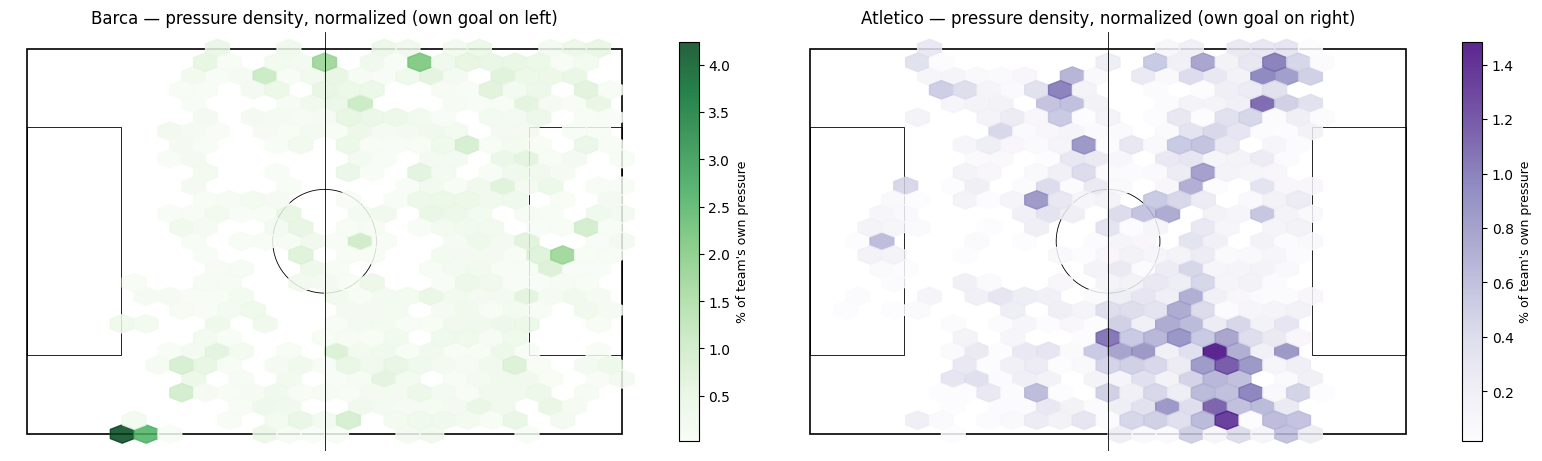

In [17]:
BOUNDS_TOLERANCE_M = 2.0

pressure_points = team_pressure_full[team_pressure_full["under_team_pressure"]].dropna(subset=["press_x", "press_y"]).copy()

pressure_points_clean = pressure_points[
    (pressure_points["press_x"] >= -BOUNDS_TOLERANCE_M) & (pressure_points["press_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (pressure_points["press_y"] >= -BOUNDS_TOLERANCE_M) & (pressure_points["press_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
].copy()

n_dropped = len(pressure_points) - len(pressure_points_clean)
print(f"dropped {n_dropped} / {len(pressure_points)} pressure points outside pitch bounds (+/- {BOUNDS_TOLERANCE_M}m)")
print(pressure_points_clean.groupby("team").size())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, team_id, label, cmap in zip(axes, [0, 1], ["Barca", "Atletico"], ["Greens", "Purples"]):
    sub = pressure_points_clean[pressure_points_clean["team"] == team_id]

    ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
    ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.6)
    ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.6))
    box_depth, box_width = 16.5, 40.3
    ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.6))
    ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.6))

    weights = np.full(len(sub), 1.0 / len(sub) * 100)
    hb = ax.hexbin(sub["press_x"], sub["press_y"], C=weights, reduce_C_function=np.sum,
                    gridsize=25, cmap=cmap, mincnt=1, extent=(0, PITCH_LENGTH, 0, PITCH_WIDTH), alpha=0.85)
    cb = plt.colorbar(hb, ax=ax, shrink=0.7)
    cb.set_label("% of team's own pressure", fontsize=9)

    own_goal_side = "left" if team_id == 0 else "right"
    ax.set_title(f"{label} — pressure density, normalized (own goal on {own_goal_side})", fontsize=12)
    ax.set_xlim(-3, PITCH_LENGTH + 3)
    ax.set_ylim(-3, PITCH_WIDTH + 3)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [18]:
## Diagnostic: what's driving the concentrated corner-zone pressure cluster for team 0
## Checks whether the dark hex near the corner is one sustained passage of play or genuinely
## distributed events -- needed before deciding whether to change the in_own_box exclusion.

CORNER_ZONE_X_MAX = 30  # just beyond the 16.5m box exclusion, catches the corner/wide-defending band

corner_zone_events = team_pressure_events[
    (team_pressure_events["team"] == 0)
].copy()

# re-attach zone info by checking the ball position at event midpoint
corner_zone_events["mid_frame"] = ((corner_zone_events["start_frame"] + corner_zone_events["end_frame"]) / 2).astype(int)
ball_x_lookup = ball_frame_table.set_index("frame_idx")["ball_pitch_x"]
corner_zone_events["mid_press_x"] = corner_zone_events["mid_frame"].map(ball_x_lookup)

corner_zone_events = corner_zone_events[
    (corner_zone_events["mid_press_x"] > BOX_DEPTH_M) & (corner_zone_events["mid_press_x"] <= CORNER_ZONE_X_MAX)
].sort_values("duration_sec", ascending=False)

print(f"team 0 pressure events with midpoint between {BOX_DEPTH_M}m and {CORNER_ZONE_X_MAX}m from own goal:")
print(f"{len(corner_zone_events)} events, {corner_zone_events['duration_sec'].sum():.1f}s total")
print()
print(corner_zone_events[["start_frame", "end_frame", "duration_sec", "mean_n_pressing"]].head(10))

team 0 pressure events with midpoint between 16.5m and 30m from own goal:
7 events, 13.7s total

     start_frame  end_frame  duration_sec  mean_n_pressing
68         56826      56989          5.60         0.128571
54         47220      47287          2.72         0.000000
55         47432      47492          2.44         0.000000
69         57574      57596          0.92         1.000000
40         35253      35272          0.80         1.300000
101        67514      67663          0.68         0.000000
103        68769      68782          0.56         0.000000


## 12. Possession events (keep-last gap fill) + pressure per event
Match is split into possession events by forward-filling every no-carrier (NONE) gap onto the last known `possession_team`, then run-length-encoding the result. For each event, the out-of-possession team's frame-level pressure signal (section 3) is averaged over that event's frames; the final per-team number is a duration-weighted mean across events, so a 40s press counts more than a 2s one.

In [19]:
poss_raw = ball_frame_table[["frame_idx", "possession_team"]].sort_values("frame_idx").reset_index(drop=True)
poss_raw = poss_raw.merge(stoppage_frame_lookup.rename("is_stoppage"), left_on="frame_idx", right_index=True, how="left")
poss_raw["is_stoppage"] = poss_raw["is_stoppage"].fillna(False)

poss_raw["possession_team_filled"] = poss_raw["possession_team"].ffill()
poss_raw = poss_raw.dropna(subset=["possession_team_filled"]).reset_index(drop=True)
poss_raw["possession_team_filled"] = poss_raw["possession_team_filled"].astype(int)

# force a hard break at every stoppage -- even if the same team has the ball before and after,
# dead time should never let two possession events merge into one
poss_raw["grouping_state"] = np.where(poss_raw["is_stoppage"], -1, poss_raw["possession_team_filled"])
poss_raw["event_id"] = (poss_raw["grouping_state"] != poss_raw["grouping_state"].shift()).cumsum()

# drop the stoppage rows themselves -- dead time shouldn't count toward any event's duration,
# but the split they forced above is preserved
poss_raw_live = poss_raw[~poss_raw["is_stoppage"]].reset_index(drop=True)

possession_events = (
    poss_raw_live.groupby("event_id", as_index=False)
    .agg(
        possession_team=("possession_team_filled", "first"),
        start_frame=("frame_idx", "first"),
        end_frame=("frame_idx", "last"),
        n_frames=("frame_idx", "count"),
    )
)
possession_events["duration_sec"] = possession_events["n_frames"] / FPS
possession_events["pressing_team"] = 1 - possession_events["possession_team"]

print(f"{len(possession_events)} possession events (keep-last gap fill, split at stoppages >= {STOPPAGE_GAP_SEC}s)")
print(possession_events["duration_sec"].describe())

207 possession events (keep-last gap fill, split at stoppages >= 10.0s)
count    207.000000
mean      11.410048
std       13.179058
min        0.360000
25%        2.320000
50%        5.960000
75%       15.960000
max       78.640000
Name: duration_sec, dtype: float64


In [20]:
frame_to_event = poss_raw_live[["frame_idx", "event_id", "possession_team_filled"]]

tpf_events = tpf.merge(frame_to_event, on="frame_idx", how="inner")
# keep only rows where tpf's pressing team actually matches this event's out-of-possession team --
# drops the rare frames where raw carrier_team briefly disagreed with the smoothed possession_team
tpf_events = tpf_events[tpf_events["team"] != tpf_events["possession_team_filled"]].copy()

event_pressure = (
    tpf_events.groupby("event_id", as_index=False)
    .agg(
        mean_n_pressing=("n_pressing", "mean"),
        mean_frac_tight_blocked=("frac_tight_blocked", "mean"),
        pct_frames_under_pressure=("under_team_pressure", "mean"),
        n_frames_matched=("frame_idx", "count"),
    )
)

possession_events = possession_events.merge(event_pressure, on="event_id", how="left")
matched = possession_events["pct_frames_under_pressure"].notna().sum()
print(f"pressure computed for {matched} / {len(possession_events)} events "
      f"(unmatched events are ones where raw carrier_team never agreed with the filled possession_team)")

scored = possession_events.dropna(subset=["pct_frames_under_pressure"])

final_pressure_by_team = (
    scored.groupby("pressing_team")
    .apply(lambda g: pd.Series({
        "duration_weighted_pct_under_pressure": np.average(g["pct_frames_under_pressure"], weights=g["duration_sec"]) * 100,
        "simple_mean_pct_under_pressure": g["pct_frames_under_pressure"].mean() * 100,
        "n_events": len(g),
        "total_duration_sec": g["duration_sec"].sum(),
    }))
)
print("\nfinal pressure by pressing team (duration-weighted mean is the headline number):")
print(final_pressure_by_team)

pressure computed for 207 / 207 events (unmatched events are ones where raw carrier_team never agreed with the filled possession_team)

final pressure by pressing team (duration-weighted mean is the headline number):
               duration_weighted_pct_under_pressure  \
pressing_team                                         
0                                         33.428840   
1                                         26.495141   

               simple_mean_pct_under_pressure  n_events  total_duration_sec  
pressing_team                                                                
0                                   32.864769     106.0              989.64  
1                                   26.461766     101.0             1372.24  


C:\Users\user\AppData\Local\Temp\ipykernel_15456\624361213.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## 13. PPDA (Passes per Defensive Action)
Measures pressing intensity: how many passes a team allows its opponent to complete outside *that team's own defensive third* (i.e. excluding their own last-ditch defending near their own goal) before making a defensive action -- an interception or a tackle (the close-range team-change transitions captured above) -- in that same zone. Lower PPDA = more aggressive, higher-up pressing. Both the numerator and denominator are classified relative to the *defending* team (whichever team's PPDA is being computed), not the team that had the ball -- a defensive action near your own goal is just normal defending and shouldn't count as pressing, regardless of who had possession. Goalkeeper saves/claims are already excluded from `defensive_actions` at the source, so shot-stopping doesn't get counted as a pressing action.

In [21]:
def zone_for_team(x, team):
    if pd.isna(x):
        return None
    if team == 0:
        if x < 35: return "own_third"
        elif x < 70: return "middle_third"
        else: return "attacking_third"
    else:
        if x > 70: return "own_third"
        elif x > 35: return "middle_third"
        else: return "attacking_third"

ppda_by_team = {}
ppda_detail = {}

for team_id in [0, 1]:
    opponent = 1 - team_id

    # numerator: opponent's completed passes, classified in THIS team's own zone convention --
    # excluded only when they happen in this team's own defensive third (last-ditch territory)
    opp_completed = passes_from_scratch[
        (passes_from_scratch["outcome"] == "completed") &
        (passes_from_scratch["passer_team"] == opponent)
    ].copy()
    opp_completed["zone"] = opp_completed["release_x"].apply(lambda x: zone_for_team(x, team_id))
    passes_allowed = int((opp_completed["zone"] != "own_third").sum())

    # denominator: this team's own defensive actions, same zone convention
    own_actions = defensive_actions[defensive_actions["defending_team"] == team_id].copy()
    own_actions["zone"] = own_actions["x"].apply(lambda x: zone_for_team(x, team_id))
    actions_made = int((own_actions["zone"] != "own_third").sum())

    ppda_by_team[team_id] = passes_allowed / actions_made if actions_made > 0 else np.nan
    ppda_detail[team_id] = {"passes_allowed": passes_allowed, "actions_made": actions_made}

print("passes allowed / defensive actions made, by team (excluding each team's own defensive third):")
for team_id in [0, 1]:
    print(f"team {team_id}: {ppda_detail[team_id]}")

print("\nPPDA by team (lower = more aggressive pressing):")
for team_id, val in ppda_by_team.items():
    print(f"team {team_id}: {val:.2f}")

passes allowed / defensive actions made, by team (excluding each team's own defensive third):
team 0: {'passes_allowed': 119, 'actions_made': 49}
team 1: {'passes_allowed': 158, 'actions_made': 25}

PPDA by team (lower = more aggressive pressing):
team 0: 2.43
team 1: 6.32


## 14. Pressure effectiveness — co-press count, intensity over time, regain rate
Three cheap additions on top of the already-validated pressure signal (section 3) and raw carrier data (section 8): how many defenders press together per event, whether pressing intensity holds up across the match, and how often pressure actually wins the ball back. These are the numbers most worth handing to an LLM downstream -- volume alone ("pressed for 32% of the time") says little without effectiveness attached.

In [22]:
# --- co-press count per event: lone chaser vs coordinated press ---
copress_records = []
for team_id, grp in team_pressure_events.groupby("team"):
    team_frames = tpf[tpf["team"] == team_id].sort_values("frame_idx")
    fidx = team_frames["frame_idx"].values
    npress = team_frames["n_pressing"].values
    starts = np.searchsorted(fidx, grp["start_frame"].values, side="left")
    ends = np.searchsorted(fidx, grp["end_frame"].values, side="right")
    for (idx, row), s, e in zip(grp.iterrows(), starts, ends):
        seg = npress[s:e]
        copress_records.append({
            "event_index": idx,
            "max_n_pressing": seg.max() if len(seg) else np.nan,
            "mean_n_pressing_event": seg.mean() if len(seg) else np.nan,
        })

copress_df = pd.DataFrame(copress_records).set_index("event_index")
team_pressure_events = team_pressure_events.join(copress_df)

print("max simultaneous pressers per event, by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].describe())

print("\nshare of events that were a coordinated press (max_n_pressing >= 2), by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].apply(lambda s: (s >= 2).mean() * 100).round(1))

max simultaneous pressers per event, by team:
      count      mean       std  min  25%  50%  75%  max
team                                                    
0     105.0  1.285714  0.977775  0.0  1.0  1.0  2.0  4.0
1     144.0  1.125000  0.907429  0.0  0.0  1.0  2.0  4.0

share of events that were a coordinated press (max_n_pressing >= 2), by team:
team
0    40.0
1    33.3
Name: max_n_pressing, dtype: float64


In [23]:
# --- pressing intensity over match time (5-minute bins), chronologically sorted, stoppages excluded ---
BIN_MINUTES = 5

tpf_binned = tpf.merge(stoppage_frame_lookup.rename("is_stoppage"), left_on="frame_idx", right_index=True, how="left")
tpf_binned["is_stoppage"] = tpf_binned["is_stoppage"].fillna(False)
tpf_binned = tpf_binned[~tpf_binned["is_stoppage"]].copy()
tpf_binned["time_bin"] = (tpf_binned["frame_idx"] / FPS // (BIN_MINUTES * 60)).astype(int)

pressing_by_bin = (
    tpf_binned.groupby(["team", "time_bin"])["under_team_pressure"]
    .mean()
    .reset_index()
    .rename(columns={"under_team_pressure": "pct_under_pressure"})
)
pressing_by_bin["pct_under_pressure"] = (pressing_by_bin["pct_under_pressure"] * 100).round(1)
pressing_by_bin["bin_label"] = pressing_by_bin["time_bin"].apply(
    lambda b: f"{b * BIN_MINUTES}-{(b + 1) * BIN_MINUTES}min"
)

pressing_intensity_timeline = (
    pressing_by_bin
    .sort_values("time_bin")
    .pivot(index="bin_label", columns="team", values="pct_under_pressure")
)
ordered_labels = pressing_by_bin.sort_values("time_bin")["bin_label"].unique()
pressing_intensity_timeline = pressing_intensity_timeline.loc[ordered_labels]

print("pressing intensity (% of out-of-possession time under pressure) by 5-minute bin, stoppages excluded:")
print(pressing_intensity_timeline)

pressing intensity (% of out-of-possession time under pressure) by 5-minute bin, stoppages excluded:
team          0     1
bin_label            
0-5min     46.0  23.9
5-10min    38.0  23.1
10-15min   26.4  32.2
15-20min   55.6  24.4
20-25min   39.0  20.7
25-30min   21.1  33.7
30-35min   34.3  27.3
35-40min   35.8  31.9
40-45min   36.3  24.0
45-50min   11.5  57.8


In [24]:
# --- mask low-sample bins: a bin with too few frames lets one short sequence swing the average ---
MIN_BIN_FRAMES = 500

# rebuild fresh from pressing_by_bin every time -- avoids mutating a possibly-stale table
# if this cell is re-run more than once or out of order
pressing_intensity_timeline = (
    pressing_by_bin
    .sort_values("time_bin")
    .pivot(index="bin_label", columns="team", values="pct_under_pressure")
)
ordered_labels = pressing_by_bin.sort_values("time_bin")["bin_label"].unique()
pressing_intensity_timeline = pressing_intensity_timeline.loc[ordered_labels]

bin_frame_counts = tpf_binned.groupby(["team", "time_bin"]).size().reset_index(name="n_frames")
bin_frame_counts["bin_label"] = bin_frame_counts["time_bin"].apply(
    lambda b: f"{b * BIN_MINUTES}-{(b + 1) * BIN_MINUTES}min"
)

low_sample = bin_frame_counts[bin_frame_counts["n_frames"] < MIN_BIN_FRAMES]

for _, row in low_sample.iterrows():
    pressing_intensity_timeline.loc[row["bin_label"], row["team"]] = np.nan

print(f"masked {len(low_sample)} team/bin cell(s) below MIN_BIN_FRAMES={MIN_BIN_FRAMES} (unreliable sample size):")
print(low_sample[["bin_label", "team", "n_frames"]])

print("\npressing intensity timeline, low-sample bins masked as NaN:")
print(pressing_intensity_timeline)

masked 1 team/bin cell(s) below MIN_BIN_FRAMES=500 (unreliable sample size):
   bin_label  team  n_frames
19  45-50min     1       223

pressing intensity timeline, low-sample bins masked as NaN:
team          0     1
bin_label            
0-5min     46.0  23.9
5-10min    38.0  23.1
10-15min   26.4  32.2
15-20min   55.6  24.4
20-25min   39.0  20.7
25-30min   21.1  33.7
30-35min   34.3  27.3
35-40min   35.8  31.9
40-45min   36.3  24.0
45-50min   11.5   NaN


In [25]:
# --- pressure -> regain conversion rate ---
MAX_REGAIN_SEC = 5.0
MAX_REGAIN_FRAMES = int(MAX_REGAIN_SEC * FPS)

raw_carrier_lookup = (
    ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]]
    .sort_values("frame_idx")
)
_carrier_frame_idx = raw_carrier_lookup["frame_idx"].values
_carrier_team_vals = raw_carrier_lookup["carrier_team"].values

def regained_within_window(team_id, end_frame):
    lo = np.searchsorted(_carrier_frame_idx, end_frame, side="left")
    hi = np.searchsorted(_carrier_frame_idx, end_frame + MAX_REGAIN_FRAMES, side="right")
    window_teams = _carrier_team_vals[lo:hi]
    return bool(np.any(window_teams == team_id))

team_pressure_events["regained_ball"] = team_pressure_events.apply(
    lambda r: regained_within_window(r["team"], r["end_frame"]), axis=1
)

regain_summary = (
    team_pressure_events.groupby("team")["regained_ball"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "regain_rate"})
)
regain_summary["regain_rate"] = (regain_summary["regain_rate"] * 100).round(1)
print(f"pressure -> regain conversion rate (ball won back by the pressing team within {MAX_REGAIN_SEC}s of the event ending):")
print(regain_summary)

pressure -> regain conversion rate (ball won back by the pressing team within 5.0s of the event ending):
      regain_rate  sum  count
team                         
0            40.0   42    105
1            25.7   37    144


## 15. Pressure outcome taxonomy
Pressure *volume* (`under_team_pressure`, PPDA, regain rate) says a press happened -- it doesn't say what it did to the buildup. This section classifies every resolved carrier transition into what actually happened to it: progressed forward anyway, forced backward, forced sideways, lost to an interception, lost to a tackle, or lost to a long ball / unresolved gap (previously dropped entirely by the `MAX_RECEPTION_GAP_FRAMES` filter in section 10). Same `under_pressure` definition as section 10 -- sustained pressure in the lookback window, not a single flickering frame.

This is the table meant for the LLM narrative layer: it turns "Barca pressed for 42% of Atletico's possession" into "Barca's press forced backward or sideways passes on X% of pressured touches, on top of the Y% won back outright" -- causal language a raw pressure-time percentage can't produce.

In [26]:
FORWARD_PROGRESS_THRESH_M = 3.0   # net advance toward the attacking goal, in the team's own attack direction
BACKWARD_THRESH_M = -3.0          # net retreat away from the attacking goal

def receiver_position(row):
    try:
        pos = pos_lookup.loc[(row["reception_frame"], row["receiver_track_id"])]
        return pos["pitch_x"], pos["pitch_y"]
    except KeyError:
        return np.nan, np.nan

recv_xy = passes_from_scratch.apply(receiver_position, axis=1, result_type="expand")
passes_from_scratch["receiver_x"] = recv_xy[0]
passes_from_scratch["receiver_y"] = recv_xy[1]

def progression_m(row):
    # positive = net advance toward the attacking goal, negative = net retreat, direction-corrected per team
    if pd.isna(row["receiver_x"]):
        return np.nan
    if row["passer_team"] == 0:
        return row["receiver_x"] - row["release_x"]
    else:
        return row["release_x"] - row["receiver_x"]

passes_from_scratch["progression_m"] = passes_from_scratch.apply(progression_m, axis=1)

def classify_pass_outcome(row):
    if row["outcome"] == "intercepted":
        return "lost_intercepted"
    if pd.isna(row["progression_m"]):
        return "unresolved"  # receiver position missing from player_frame_table at reception frame
    if row["progression_m"] >= FORWARD_PROGRESS_THRESH_M:
        return "progressed_forward"
    elif row["progression_m"] <= BACKWARD_THRESH_M:
        return "forced_backward"
    else:
        return "forced_sideways"

passes_from_scratch["pass_outcome_detail"] = passes_from_scratch.apply(classify_pass_outcome, axis=1)

print("pass outcome breakdown, under pressure vs not, by team:")
print(passes_from_scratch.groupby(["passer_team", "under_pressure", "pass_outcome_detail"]).size().unstack(fill_value=0))

pass outcome breakdown, under pressure vs not, by team:
pass_outcome_detail         forced_backward  forced_sideways  \
passer_team under_pressure                                     
0           False                        35               33   
            True                         30               16   
1           False                        27               20   
            True                         24               14   

pass_outcome_detail         lost_intercepted  progressed_forward  
passer_team under_pressure                                        
0           False                         26                  65  
            True                          15                  27  
1           False                         21                  24  
            True                          23                  19  


In [27]:
# --- tackles (already detected in section 10 as short-distance, different-team transitions,
#     but excluded from passes_from_scratch entirely -- pull them in as their own outcome) ---
tackle_outcomes = defensive_actions[defensive_actions["action_type"] == "tackle"][
    ["attacking_team", "frame"]
].rename(columns={"attacking_team": "team"}).copy()
tackle_outcomes["under_pressure"] = tackle_outcomes.apply(
    lambda r: was_under_pressure(r["team"], r["frame"]), axis=1
)
tackle_outcomes["pass_outcome_detail"] = "lost_tackled"
tackle_outcomes = tackle_outcomes.drop(columns="frame")

# --- large-gap carrier transitions (gap_frames > MAX_RECEPTION_GAP_FRAMES), previously dropped
#     silently in section 10 -- capture as their own bucket: ball retained after the gap
#     (throw-in, stoppage, loose-ball scramble the same team won back) vs lost after it ---
long_gap_records = []
for i in range(len(carrier_runs_full) - 1):
    passer = carrier_runs_full.loc[i]
    receiver = carrier_runs_full.loc[i + 1]
    gap_frames = receiver["start_frame"] - passer["end_frame"]
    if gap_frames <= MAX_RECEPTION_GAP_FRAMES:
        continue  # already handled above as a resolved pass / interception / tackle

    same_team = receiver["team"] == passer["team"]
    long_gap_records.append({
        "team": int(passer["team"]),
        "frame": int(passer["end_frame"]),
        "reception_frame": int(receiver["start_frame"]),
        "under_pressure": was_under_pressure(passer["team"], passer["end_frame"]),
        "pass_outcome_detail": "retained_after_gap" if same_team else "lost_after_long_ball",
    })

long_gap_events = pd.DataFrame(long_gap_records)
print(f"{len(long_gap_events)} large-gap transitions captured (previously dropped entirely)")
if len(long_gap_events):
    print(long_gap_events.groupby(["team", "under_pressure", "pass_outcome_detail"]).size())

162 large-gap transitions captured (previously dropped entirely)
team  under_pressure  pass_outcome_detail 
0     False           lost_after_long_ball    33
                      retained_after_gap      38
      True            lost_after_long_ball     4
                      retained_after_gap      14
1     False           lost_after_long_ball    25
                      retained_after_gap      30
      True            lost_after_long_ball    10
                      retained_after_gap       8
dtype: int64


In [28]:
# --- unified outcome table: every resolved carrier transition, one row each, ready for the LLM layer ---
FINAL_OUTCOME_ORDER = [
    "progressed_forward", "forced_sideways", "forced_backward",
    "lost_intercepted", "lost_tackled", "lost_after_long_ball",
    "retained_after_gap", "unresolved",
]

pass_outcomes = passes_from_scratch[["passer_team", "under_pressure", "pass_outcome_detail"]].rename(
    columns={"passer_team": "team"}
)

outcome_events = pd.concat([pass_outcomes, tackle_outcomes, long_gap_events], ignore_index=True)
outcome_events["pass_outcome_detail"] = pd.Categorical(
    outcome_events["pass_outcome_detail"], categories=FINAL_OUTCOME_ORDER, ordered=True
)

outcome_counts = (
    outcome_events.groupby(["team", "under_pressure", "pass_outcome_detail"], observed=False)
    .size()
    .unstack(fill_value=0)
)
print("carrier-transition outcomes by team and pressure state (counts):")
print(outcome_counts)

outcome_pct = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100
print("\nsame table as % within each team/pressure-state row:")
print(outcome_pct.round(1))

# headline: of the carrier actions a team made WHILE UNDER PRESSURE, what share were disrupted
# in some way (not clean forward progression) -- this is the opponent's press-effectiveness number,
# so index it by the team that got disrupted and remember the credit belongs to (1 - team)
DISRUPTIVE = ["forced_backward", "forced_sideways", "lost_intercepted", "lost_tackled", "lost_after_long_ball"]
pressured = outcome_events[outcome_events["under_pressure"] == True].copy()
pressured["disrupted"] = pressured["pass_outcome_detail"].isin(DISRUPTIVE)
disruption_rate = pressured.groupby("team")["disrupted"].mean() * 100

print("\n% of a team's own pressured carrier actions that were disrupted in some way")
print("(credit for the disruption belongs to the OPPOSING team's press):")
print(disruption_rate.round(1))

carrier-transition outcomes by team and pressure state (counts):
pass_outcome_detail  progressed_forward  forced_sideways  forced_backward  \
team under_pressure                                                         
0    False                           65               33               35   
     True                            27               16               30   
1    False                           24               20               27   
     True                            19               14               24   

pass_outcome_detail  lost_intercepted  lost_tackled  lost_after_long_ball  \
team under_pressure                                                         
0    False                         26            11                    33   
     True                          15             3                     4   
1    False                         21             6                    25   
     True                          23             5                    10   

pass_outc

## 15b. Pressure outcome taxonomy by pitch zone
Same taxonomy as section 15, split by the zone each transition happened in -- reuses `zone_for_team` from section 13 (PPDA), so the zone convention matches everywhere else in the notebook. Tells you not just how effective a team's pressure was, but *where*: winning the ball back in the attacking third is worth far more than shepherding it sideways in your own defensive third, and the flat section-15 numbers can't distinguish the two.

In [29]:
# --- rebuild the three outcome sources with a zone column attached ---

pass_outcomes_z = passes_from_scratch[["passer_team", "under_pressure", "pass_outcome_detail", "release_x"]].rename(
    columns={"passer_team": "team"}
).copy()
pass_outcomes_z["zone"] = pass_outcomes_z.apply(lambda r: zone_for_team(r["release_x"], r["team"]), axis=1)
pass_outcomes_z = pass_outcomes_z.drop(columns="release_x")

tackle_outcomes_z = defensive_actions[defensive_actions["action_type"] == "tackle"][
    ["attacking_team", "frame", "x"]
].rename(columns={"attacking_team": "team"}).copy()
tackle_outcomes_z["under_pressure"] = tackle_outcomes_z.apply(
    lambda r: was_under_pressure(r["team"], r["frame"]), axis=1
)
tackle_outcomes_z["pass_outcome_detail"] = "lost_tackled"
tackle_outcomes_z["zone"] = tackle_outcomes_z.apply(lambda r: zone_for_team(r["x"], r["team"]), axis=1)
tackle_outcomes_z = tackle_outcomes_z.drop(columns=["frame", "x"])

long_gap_records_z = []
for i in range(len(carrier_runs_full) - 1):
    passer = carrier_runs_full.loc[i]
    receiver = carrier_runs_full.loc[i + 1]
    gap_frames = receiver["start_frame"] - passer["end_frame"]
    if gap_frames <= MAX_RECEPTION_GAP_FRAMES:
        continue  # already covered by pass_outcomes_z / tackle_outcomes_z

    try:
        release_x = pos_lookup.loc[(passer["end_frame"], passer["track_id"])]["pitch_x"]
    except KeyError:
        release_x = np.nan

    same_team = receiver["team"] == passer["team"]
    long_gap_records_z.append({
        "team": int(passer["team"]),
        "under_pressure": was_under_pressure(passer["team"], passer["end_frame"]),
        "pass_outcome_detail": "retained_after_gap" if same_team else "lost_after_long_ball",
        "zone": zone_for_team(release_x, int(passer["team"])) if pd.notna(release_x) else None,
    })

long_gap_events_z = pd.DataFrame(long_gap_records_z)

outcome_events_z = pd.concat([pass_outcomes_z, tackle_outcomes_z, long_gap_events_z], ignore_index=True)
outcome_events_z["pass_outcome_detail"] = pd.Categorical(
    outcome_events_z["pass_outcome_detail"], categories=FINAL_OUTCOME_ORDER, ordered=True
)

n_missing_zone = outcome_events_z["zone"].isna().sum()
print(f"{n_missing_zone} events with unresolvable zone (missing position), dropped from the zone breakdown")
outcome_events_z = outcome_events_z.dropna(subset=["zone"])

13 events with unresolvable zone (missing position), dropped from the zone breakdown


In [30]:
# --- disruption rate and turnover rate, by team and zone, pressured actions only ---
ZONE_ORDER = ["own_third", "middle_third", "attacking_third"]

pressured_z = outcome_events_z[outcome_events_z["under_pressure"] == True].copy()
pressured_z["disrupted"] = pressured_z["pass_outcome_detail"].isin(DISRUPTIVE)
pressured_z["turned_over"] = pressured_z["pass_outcome_detail"].isin(
    ["lost_intercepted", "lost_tackled", "lost_after_long_ball"]
)

zone_summary = (
    pressured_z.groupby(["team", "zone"])
    .agg(n_events=("disrupted", "size"), disruption_rate=("disrupted", "mean"), turnover_rate=("turned_over", "mean"))
)
zone_summary["disruption_rate"] = (zone_summary["disruption_rate"] * 100).round(1)
zone_summary["turnover_rate"] = (zone_summary["turnover_rate"] * 100).round(1)
zone_summary = zone_summary.reindex(pd.MultiIndex.from_product([[0, 1], ZONE_ORDER], names=["team", "zone"]))

print("of a team's own pressured actions in each zone -- disruption rate and turnover rate")
print("(zone is relative to the team whose action this is; credit for the disruption/turnover belongs to the opponent's press):")
print(zone_summary)

of a team's own pressured actions in each zone -- disruption rate and turnover rate
(zone is relative to the team whose action this is; credit for the disruption/turnover belongs to the opponent's press):
                      n_events  disruption_rate  turnover_rate
team zone                                                     
0    own_third              13             53.8           23.1
     middle_third           64             59.4           17.2
     attacking_third        31             74.2           25.8
1    own_third              54             70.4           38.9
     middle_third           41             75.6           31.7
     attacking_third         8             87.5           50.0


## 16. Pressing triggers -- what state the receiver was in right before pressure arrived
No body-orientation model in the pipeline, so "back to goal" isn't directly measurable. These are position/motion-based proxies for the classic situations that invite a press: receiving near the touchline (options cut off on one side), receiving deep in your own third, receiving a backward-directed pass (reuses `progression_m` from section 15 -- ball was moving toward the receiver's own goal), receiving with few open passing lanes (reuses `frame_lane_summary` from section 2 -- isolated), and a slow/static first touch. For every completed pass reception, checks whether the receiving team came under opponent pressure within `PRESS_ONSET_WINDOW_SEC`, then reports how often a press actually follows each trigger vs the baseline rate.

In [31]:
PRESS_ONSET_WINDOW_SEC = 2.0
PRESS_ONSET_WINDOW_FRAMES = int(PRESS_ONSET_WINDOW_SEC * FPS)
TOUCHLINE_DIST_THRESH_M = 8.0
ISOLATED_LANES_THRESH = 2  # fewer than this many open passing lanes counts as isolated

reception_triggers = passes_from_scratch[passes_from_scratch["outcome"] == "completed"][
    ["receiver_track_id", "passer_team", "reception_frame", "receiver_x", "receiver_y", "progression_m"]
].rename(columns={"passer_team": "team"}).dropna(subset=["receiver_x", "receiver_y"]).copy()

reception_triggers["zone"] = reception_triggers.apply(lambda r: zone_for_team(r["receiver_x"], r["team"]), axis=1)
reception_triggers["dist_to_touchline_m"] = np.minimum(
    reception_triggers["receiver_y"], PITCH_WIDTH - reception_triggers["receiver_y"]
)

reception_triggers["trigger_touchline"] = reception_triggers["dist_to_touchline_m"] < TOUCHLINE_DIST_THRESH_M
reception_triggers["trigger_deep_own_third"] = reception_triggers["zone"] == "own_third"
reception_triggers["trigger_backward_pass"] = reception_triggers["progression_m"] < 0

# open passing lanes at the reception frame, reusing frame_lane_summary from section 2
lane_lookup = frame_lane_summary.set_index("frame_idx")["n_lanes_open"]
reception_triggers["n_lanes_open"] = reception_triggers["reception_frame"].map(lane_lookup)
reception_triggers["trigger_isolated"] = reception_triggers["n_lanes_open"] < ISOLATED_LANES_THRESH

print(f"{reception_triggers['n_lanes_open'].isna().sum()} receptions with no lane data at that frame (dropped from trigger_isolated only)")

0 receptions with no lane data at that frame (dropped from trigger_isolated only)


In [32]:
# --- first-touch speed: how quickly the receiver moved the ball in the moment right after control ---
FIRST_TOUCH_WINDOW_FRAMES = int(0.4 * FPS)  # ~0.4s right after the touch
STATIC_TOUCH_SPEED_MPS = 1.5

def first_touch_speed(row):
    try:
        p0 = pos_lookup.loc[(row["reception_frame"], row["receiver_track_id"])]
        p1 = pos_lookup.loc[(row["reception_frame"] + FIRST_TOUCH_WINDOW_FRAMES, row["receiver_track_id"])]
    except KeyError:
        return np.nan
    dist_m = float(np.hypot(p1["pitch_x"] - p0["pitch_x"], p1["pitch_y"] - p0["pitch_y"]))
    return dist_m / (FIRST_TOUCH_WINDOW_FRAMES / FPS)

reception_triggers["first_touch_speed_mps"] = reception_triggers.apply(first_touch_speed, axis=1)
reception_triggers["trigger_static_touch"] = reception_triggers["first_touch_speed_mps"] < STATIC_TOUCH_SPEED_MPS

print(f"{reception_triggers['first_touch_speed_mps'].isna().sum()} receptions with no first-touch speed "
      f"(receiver missing from player_frame_table {FIRST_TOUCH_WINDOW_FRAMES} frames later -- likely a pass near a stoppage)")

3 receptions with no first-touch speed (receiver missing from player_frame_table 10 frames later -- likely a pass near a stoppage)


In [33]:
# --- did opponent pressure actually follow this reception, within PRESS_ONSET_WINDOW_SEC? ---
def press_follows_reception(row):
    team = int(row["team"])
    opponent = 1 - team
    frame0 = int(row["reception_frame"])
    for f in range(frame0, frame0 + PRESS_ONSET_WINDOW_FRAMES + 1):
        if press_flags.get((f, opponent), False):
            return True
    return False

reception_triggers["press_followed"] = reception_triggers.apply(press_follows_reception, axis=1)

TRIGGER_COLS = ["trigger_touchline", "trigger_deep_own_third", "trigger_backward_pass",
                "trigger_isolated", "trigger_static_touch"]

baseline_rate = reception_triggers["press_followed"].mean() * 100
print(f"baseline: a press follows any reception {baseline_rate:.1f}% of the time (n={len(reception_triggers)})\n")

for col in TRIGGER_COLS:
    with_trigger = reception_triggers[reception_triggers[col] == True]
    without_trigger = reception_triggers[reception_triggers[col] == False]
    print(f"{col}: press followed {with_trigger['press_followed'].mean()*100:.1f}% of the time "
          f"(n={len(with_trigger)}) vs {without_trigger['press_followed'].mean()*100:.1f}% otherwise")

print("\ntrigger prevalence and press-follow rate by receiving team (%):")
print((reception_triggers.groupby("team")[TRIGGER_COLS + ["press_followed"]].mean() * 100).round(1))

baseline: a press follows any reception 68.6% of the time (n=334)

trigger_touchline: press followed 90.5% of the time (n=74) vs 62.3% otherwise
trigger_deep_own_third: press followed 59.4% of the time (n=96) vs 72.3% otherwise
trigger_backward_pass: press followed 65.6% of the time (n=154) vs 71.1% otherwise
trigger_isolated: press followed 94.7% of the time (n=19) vs 67.0% otherwise
trigger_static_touch: press followed 61.4% of the time (n=88) vs 71.1% otherwise

trigger prevalence and press-follow rate by receiving team (%):
      trigger_touchline  trigger_deep_own_third  trigger_backward_pass  \
team                                                                     
0                  19.4                    17.5                   41.7   
1                  26.6                    46.9                   53.1   

      trigger_isolated  trigger_static_touch  press_followed  
team                                                          
0                  4.4                  20.

## 17. Team pressing profile -- summary
One table per team pulling together volume (section 4/12), effectiveness by zone (15b), counter-press response speed (8b), and reception triggers (16) -- everything an LLM narrative layer needs about a team's pressing identity in one place, instead of six separate printouts.

In [34]:
TEAM_NAMES = {0: "Barca", 1: "Atletico"}

profile_rows = []
for team_id, opponent_id in [(0, 1), (1, 0)]:
    row = {"team": TEAM_NAMES[team_id]}

    # volume + regain (section 12 / section 14) -- both indexed by the PRESSING team
    row["pct_opp_possession_pressured"] = (
        final_pressure_by_team.loc[team_id, "duration_weighted_pct_under_pressure"]
        if team_id in final_pressure_by_team.index else np.nan
    )
    row["ppda"] = ppda_by_team.get(team_id, np.nan)
    row["press_event_regain_rate_pct"] = (
        regain_summary.loc[team_id, "regain_rate"] if team_id in regain_summary.index else np.nan
    )

    # outcome/turnover effectiveness by zone (section 15b) -- indexed by the team BEING pressured,
    # so this team's press effectiveness reads from the opponent's row. zone_summary's "zone" is
    # relative to the team whose action it is (the opponent here) -- e.g. the opponent's own_third
    # is physically THIS (pressing) team's attacking_third, not its own_third. Bug found via the
    # LLM report cross-check: the old version reused the same zone label on both sides, so
    # "Barca turnover_rate_own_third" actually held Atletico-in-Atletico's-own-third (the correct
    # NUMBER, attached to a backwards column NAME). ZONE_FLIP maps a zone label from this team's
    # own perspective to the physically-equivalent label from the opponent's perspective.
    ZONE_FLIP = {"own_third": "attacking_third", "middle_third": "middle_third", "attacking_third": "own_third"}
    for zone in ["own_third", "middle_third", "attacking_third"]:
        key = (opponent_id, ZONE_FLIP[zone])
        row[f"turnover_rate_{zone}"] = zone_summary.loc[key, "turnover_rate"] if key in zone_summary.index else np.nan

    # counter-press: this team's own regain rate when THEY pressed fast after losing the ball (section 8b)
    fast_row = summary[(summary["losing_team"] == team_id) & (summary["press_response"] == "fast")]
    row["counter_press_fast_regain_rate_pct"] = (
        fast_row["regain_rate_pct"].values[0] if len(fast_row) and fast_row["turnovers"].values[0] > 0 else np.nan
    )

    # baseline: how often does this team's press actually follow an opponent's reception at all (section 16)
    opp_receptions = reception_triggers[reception_triggers["team"] == opponent_id]
    row["press_follow_rate_on_opp_receptions_pct"] = (
        opp_receptions["press_followed"].mean() * 100 if len(opp_receptions) else np.nan
    )

    profile_rows.append(row)

team_pressing_profile = pd.DataFrame(profile_rows).set_index("team").round(1)
print(team_pressing_profile.T)

team                                     Barca  Atletico
pct_opp_possession_pressured              33.4      26.5
ppda                                       2.4       6.3
press_event_regain_rate_pct               40.0      25.7
turnover_rate_own_third                   38.9      23.1
turnover_rate_middle_third                31.7      17.2
turnover_rate_attacking_third             50.0      25.8
counter_press_fast_regain_rate_pct        37.1      16.7
press_follow_rate_on_opp_receptions_pct   73.4      65.5


In [35]:
# --- one-paragraph auto-summary per team, the shape an LLM prompt actually wants ---
for team_id in [0, 1]:
    name = TEAM_NAMES[team_id]
    r = team_pressing_profile.loc[name]
    print(f"{name}:")
    print(
        f"  Pressed the opponent for {r['pct_opp_possession_pressured']:.1f}% of their out-of-possession time "
        f"(PPDA {r['ppda']:.2f}), regaining the ball within 5s of a press event {r['press_event_regain_rate_pct']:.1f}% of the time."
    )
    print(
        f"  Turnover rate when pressing: {r['turnover_rate_own_third']:.1f}% (own third) / "
        f"{r['turnover_rate_middle_third']:.1f}% (middle) / {r['turnover_rate_attacking_third']:.1f}% (attacking third)."
    )
    print(
        f"  When they pressed within 5s of losing the ball themselves, regained it {r['counter_press_fast_regain_rate_pct']:.1f}% of the time."
    )
    print()

Barca:
  Pressed the opponent for 33.4% of their out-of-possession time (PPDA 2.40), regaining the ball within 5s of a press event 40.0% of the time.
  Turnover rate when pressing: 38.9% (own third) / 31.7% (middle) / 50.0% (attacking third).
  When they pressed within 5s of losing the ball themselves, regained it 37.1% of the time.

Atletico:
  Pressed the opponent for 26.5% of their out-of-possession time (PPDA 6.30), regaining the ball within 5s of a press event 25.7% of the time.
  Turnover rate when pressing: 23.1% (own third) / 17.2% (middle) / 25.8% (attacking third).
  When they pressed within 5s of losing the ball themselves, regained it 16.7% of the time.



## 18. Team shape compactness -- width and depth of the outfield block
Per-frame team depth (distance between the back line and the front line, along each team's own attack direction -- last-3 vs front-3 outfield players, same last-3 convention as the defensive-line baseline in section 0) and width (lateral spread across the pitch, IQR-trimmed so one stray tracked position doesn't blow up the number, same safeguard `remove_outliers_iqr` uses in section 6). Restricted to out-of-possession frames -- a team's real defensive shape, not inflated by attacking-phase positioning, same convention as everywhere else in this notebook. Reuses `outfield` (in-bounds, `dist_from_own_goal` already computed) and `poss` from section 6.

Also checks whether a team's shape actually tightens while actively pressing vs its resting out-of-possession shape. (Tried linking compactness to press-event regain outcomes too -- dropped: correlations with co-press count came back near zero and the regain-outcome split produced small, inconsistent, unexplainable cells across zones and teams. Not reliable enough to keep.)

In [36]:
BACK_N = 3
FRONT_N = 3
WIDTH_IQR_MULT = 1.5
MIN_PLAYERS_FOR_SHAPE = BACK_N + FRONT_N  # need enough tracked outfield players for depth to mean anything

_shape_base = outfield.merge(poss, on="frame_idx", how="left")
_shape_base = _shape_base[
    _shape_base["possession_team"].notna() & (_shape_base["team"] != _shape_base["possession_team"])
]

def _team_frame_depth(df):
    d = df.sort_values("dist_from_own_goal")
    n = len(d)
    if n < MIN_PLAYERS_FOR_SHAPE:
        return pd.Series({"back_line_m": np.nan, "front_line_m": np.nan, "depth_m": np.nan, "n_players": n})
    back = d.head(BACK_N)["dist_from_own_goal"].mean()
    front = d.tail(FRONT_N)["dist_from_own_goal"].mean()
    return pd.Series({"back_line_m": back, "front_line_m": front, "depth_m": front - back, "n_players": n})

def _team_frame_width(y_vals):
    y = np.asarray(y_vals)
    if len(y) < 4:
        return np.nan
    q1, q3 = np.percentile(y, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - WIDTH_IQR_MULT * iqr, q3 + WIDTH_IQR_MULT * iqr
    y_trimmed = y[(y >= lo) & (y <= hi)]
    return float(y_trimmed.max() - y_trimmed.min()) if len(y_trimmed) else np.nan

depth_per_frame = _shape_base.groupby(["frame_idx", "team"]).apply(_team_frame_depth).reset_index()
depth_per_frame = depth_per_frame.dropna(subset=["depth_m"])

width_per_frame = (
    _shape_base.groupby(["frame_idx", "team"])["pitch_y"]
    .apply(_team_frame_width)
    .reset_index(name="width_m")
)

team_shape = depth_per_frame.merge(width_per_frame, on=["frame_idx", "team"], how="inner")
team_shape["compactness_area_m2"] = team_shape["depth_m"] * team_shape["width_m"]

print("out-of-possession team shape, by team (smaller area = more compact block):")
print(team_shape.groupby("team")[["depth_m", "width_m", "compactness_area_m2"]].agg(["mean", "median", "std"]))

C:\Users\user\AppData\Local\Temp\ipykernel_15456\3672017474.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depth_per_frame = _shape_base.groupby(["frame_idx", "team"]).apply(_team_frame_depth).reset_index()


out-of-possession team shape, by team (smaller area = more compact block):
        depth_m                         width_m                       \
           mean     median       std       mean     median       std   
team                                                                   
0     22.264966  22.520237  8.027249  36.671279  38.174885  9.725640   
1     19.271353  17.980540  6.821521  36.244046  36.739466  8.136595   

     compactness_area_m2                          
                    mean      median         std  
team                                              
0             847.667018  839.385927  384.141740  
1             720.610374  646.433673  345.378977  


In [37]:
# --- does a team actually get tighter when it's actively pressing, or is shape constant regardless? ---
team_shape_pressure = team_shape.merge(
    tpf[["frame_idx", "team", "under_team_pressure"]], on=["frame_idx", "team"], how="left"
)

print("compactness area (m^2) while actively pressing vs not, by team:")
print(
    team_shape_pressure.groupby(["team", "under_team_pressure"])["compactness_area_m2"]
    .agg(["mean", "median", "count"])
)

compactness area (m^2) while actively pressing vs not, by team:
                                mean      median  count
team under_team_pressure                               
0    False                863.493849  866.009513   8178
     True                 764.295185  738.095167   4311
1    False                735.813241  669.256833  14430
     True                 675.001215  600.002770   5324


## 19. Diagnostic summary
Run after executing the full notebook top to bottom. Prints the key checkpoints from every section so results can be sanity-checked in one place.

In [38]:
print("=" * 60)
print("0. STOPPAGES")
print("=" * 60)
print(f"{len(stoppages)} stoppages >= {STOPPAGE_GAP_SEC}s flagged, "
      f"{stoppages['duration_sec'].sum():.1f}s total dead time excluded from live-play calculations")

print("=" * 60)
print("1. POSSESSION EVENTS")
print("=" * 60)
print(f"{len(possession_events)} possession events (keep-last gap fill)")
print(possession_events["duration_sec"].describe())

print("\n" + "=" * 60)
print("2. PER-EVENT PRESSURE MATCH + FINAL AVERAGE")
print("=" * 60)
matched = possession_events["pct_frames_under_pressure"].notna().sum()
print(f"pressure computed for {matched} / {len(possession_events)} events "
      f"({matched / len(possession_events) * 100:.1f}%)")
print(final_pressure_by_team)

print("\n" + "=" * 60)
print("2b. PRESSING SIGNAL SANITY (gating, section 1)")
print("=" * 60)
print("share of off-ball rows within 5m that got GATED OUT (passive block, not real pressure):")
close_range = off_ball_pressure[off_ball_pressure["dist_to_carrier"] < PRESSURE_DIST_THRESH_M]
print(f"{(~close_range['is_pressuring']).mean() * 100:.1f}% of close-range rows excluded by the gate")
print("\nis_pressuring rate by team (close-range rows only):")
print(close_range.groupby("team")["is_pressuring"].mean())

print("\n" + "=" * 60)
print("3. PASS DETECTION")
print("=" * 60)
print(f"{len(passes_from_scratch)} pass attempts detected (from {len(carrier_runs_full)} carrier runs)")
print(passes_from_scratch["outcome"].value_counts())
print("\npass_distance_m stats:")
print(passes_from_scratch["pass_distance_m"].describe())
print(f"\n{len(defensive_actions)} defensive actions captured (GK saves excluded)")
print(defensive_actions["action_type"].value_counts())

print("\n" + "=" * 60)
print("4. PASSES UNDER PRESSURE")
print("=" * 60)
print("counts by team / pressure state:")
print(passes_from_scratch.groupby(["passer_team", "under_pressure"]).size())
print("\nsuccess rate table:")
print(pass_summary)

print("\n" + "=" * 60)
print("5. PPDA")
print("=" * 60)
print("passes allowed / defensive actions made, by team (excluding each team's own defensive third):")
for team_id in [0, 1]:
    print(f"team {team_id}: {ppda_detail[team_id]}")
print("\nPPDA by team (lower = more aggressive pressing):")
for team_id, val in ppda_by_team.items():
    print(f"team {team_id}: {val:.2f}")

print("\n" + "=" * 60)
print("6. PRESSURE EFFECTIVENESS (co-press, time bins, regain rate)")
print("=" * 60)
print("max simultaneous pressers per event, by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].describe())
print("\nshare of events that were a coordinated press (max_n_pressing >= 2), by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].apply(lambda s: (s >= 2).mean() * 100).round(1))
print("\npressing intensity (% of out-of-possession time under pressure) by 5-minute bin:")
print(pressing_intensity_timeline)
print(f"\npressure -> regain conversion rate (within {MAX_REGAIN_SEC}s of event end):")
print(regain_summary)

0. STOPPAGES
26 stoppages >= 10.0s flagged, 450.7s total dead time excluded from live-play calculations
1. POSSESSION EVENTS
207 possession events (keep-last gap fill)
count    207.000000
mean      11.410048
std       13.179058
min        0.360000
25%        2.320000
50%        5.960000
75%       15.960000
max       78.640000
Name: duration_sec, dtype: float64

2. PER-EVENT PRESSURE MATCH + FINAL AVERAGE
pressure computed for 207 / 207 events (100.0%)
               duration_weighted_pct_under_pressure  \
pressing_team                                         
0                                         33.428840   
1                                         26.495141   

               simple_mean_pct_under_pressure  n_events  total_duration_sec  
pressing_team                                                                
0                                   32.864769     106.0              989.64  
1                                   26.461766     101.0             1372.24  

2b. PRESSI

## 19b. Event registry - every metric in this notebook as one standard event table
Each analysis above produces its own table with its own columns. Here they are all mapped onto **one schema** so they can be listed, filtered, ranked and clipped the same way:

`uid, family, subtype, team, start_frame, end_frame, anchor_frame, zone, channel, target, score, clock, payload`

- `team` is always the **focus team** - the one doing the pressing / defending (so every clip is shown from its point of view).
- `zone` / `channel` are in that focus team's own frame (same convention as sections 5 and 5b); `target` = who the press was applied on (goalkeeper / centre-back / wide defender / midfielder / advanced player).
- `score` ranks events inside a family (the clip planner takes the best ones).

| family | source | subtypes |
|---|---|---|
| `pressure_event` | section 3 + 14 | coordinated_press, lone_chaser, lane_block_press |
| `pressure_regain` | section 14 | press_won_ball |
| `defensive_line` | section 6b | high_line, deep_line, line_step_up |
| `team_shape` | section 18 | compact_block, stretched_block |
| `counter_press` | section 8b | fast_regain, fast_no_regain, slow, never |
| `pass_under_pressure` | section 10 / 15 | forced_backward, forced_sideways, lost_intercepted, progressed_forward (press beaten) |
| `long_ball` | section 15 | lost_after_long_ball |
| `defensive_action` | section 10 / 13 | tackle, interception |
| `press_trigger` | section 16 | touchline, deep_own_third, backward_pass, isolated, static_touch |
| `possession_pressure` | section 12 | heavily_pressed, lightly_pressed |


In [ ]:
# ===== 19b. Event registry =====
MIN_SHAPE_EVENT_SEC = 3.0
MIN_POSSESSION_EVENT_SEC = 4.0
_ball_xy = ball_frame_table.set_index("frame_idx")[["ball_pitch_x", "ball_pitch_y"]]
_car_tbl = ball_frame_table.set_index("frame_idx")[["carrier_track_id", "carrier_team"]]
_n_press_lookup = tpf.set_index(["frame_idx", "team"])["n_pressing"]
ZONE_W = {"own_third": 1, "middle_third": 2, "attacking_third": 3}

def _ball_at(f0, f1):
    seg = _ball_xy.loc[f0:f1].dropna()
    return (float(seg["ball_pitch_x"].median()), float(seg["ball_pitch_y"].median())) if len(seg) else (np.nan, np.nan)

def _first_carrier(f0, f1):
    seg = _car_tbl.loc[f0:f1].dropna(subset=["carrier_track_id"])
    return (int(seg["carrier_track_id"].iloc[0]), int(seg["carrier_team"].iloc[0])) if len(seg) else (None, None)

def _press_target(cid, cteam, x, y):
    # who is being pressed: classified in the CARRIER's own frame
    if cid is None or pd.isna(x):
        return "unknown"
    if TRACK_ROLE.get(int(cid)) == "goalkeeper":
        return "goalkeeper"
    z = zone_for_team(x, cteam); ch = channel_for_team(y, cteam)
    if z == "own_third":
        return "centre-back" if ch == "centre" else "wide defender"
    return "midfielder" if z == "middle_third" else "advanced player"

def _clock(f):
    s = int(round(f / FPS)); return f"{s // 60:02d}:{s % 60:02d}"

_rows = []
def _add(family, subtype, team, f0, f1, anchor, bx_, by_, score, target=None, **payload):
    team = int(team)
    _rows.append(dict(family=family, subtype=subtype, team=team, start_frame=int(f0), end_frame=int(f1), anchor_frame=int(anchor),
                      zone=zone_for_team(bx_, team) if pd.notna(bx_) else None, channel=channel_for_team(by_, team) if pd.notna(by_) else None,
                      target=target, score=float(score) if pd.notna(score) else 0.0, payload=payload))

# 1) pressure events (+ the ones that won the ball back)
for r in team_pressure_events.itertuples():
    f0, f1 = int(r.start_frame), int(r.end_frame); bx, by = _ball_at(f0, f1)
    cid, cteam = _first_carrier(f0, f1); sx, sy = _ball_at(f0, f0 + 5)
    tgt = _press_target(cid, cteam if cteam is not None else 1 - int(r.team), sx, sy)
    maxn = 0 if pd.isna(r.max_n_pressing) else float(r.max_n_pressing)
    sub = "coordinated_press" if maxn >= 2 else ("lane_block_press" if r.mean_frac_tight_blocked >= FRAC_TIGHT_BLOCKED_THRESH else "lone_chaser")
    common = dict(max_n=maxn, mean_n=float(r.mean_n_pressing), regained=bool(r.regained_ball), duration_sec=float(r.duration_sec))
    _add("pressure_event", sub, r.team, f0, f1, f0, bx, by, r.duration_sec * max(maxn, 1), tgt, **common)
    if bool(r.regained_ball):
        _add("pressure_regain", "press_won_ball", r.team, f0, f1 + COUNTER_PRESS_WINDOW_FRAMES, f1, bx, by, r.duration_sec * max(maxn, 1) + 5, tgt, **common)

# 2) defensive line events (6b)
for r in defensive_line_events.itertuples():
    bx, by = _ball_at(r.start_frame, r.end_frame)
    sc = r.rise_m if r.subtype == "line_step_up" else r.duration_sec * abs(r.mean_line_m - line_state.loc[line_state.team == r.team, "line_last3_m"].median())
    _add("defensive_line", r.subtype, r.team, r.start_frame, r.end_frame, r.start_frame, bx, by, sc,
         mean_line_m=float(r.mean_line_m), peak_line_m=float(r.peak_line_m), rise_m=None if pd.isna(r.rise_m) else float(r.rise_m))

# 3) team shape events (18): sustained compact / stretched blocks
for _t, _g in team_shape.groupby("team"):
    _g = _g.sort_values("frame_idx"); fr_ = _g["frame_idx"].values; a_ = _g["compactness_area_m2"].values
    lo, hi = np.percentile(a_, 10), np.percentile(a_, 90)
    for sub, mask in [("compact_block", a_ <= lo), ("stretched_block", a_ >= hi)]:
        for a, b in _mask_runs(fr_, mask, max_gap=5, min_len=int(MIN_SHAPE_EVENT_SEC * FPS)):
            seg = _g[(_g["frame_idx"] >= a) & (_g["frame_idx"] <= b)]; bx, by = _ball_at(a, b)
            mean_area = seg["compactness_area_m2"].mean()
            _add("team_shape", sub, _t, a, b, a, bx, by, (b - a) / FPS * abs(mean_area - np.median(a_)) / 100,
                 depth_m=float(seg["depth_m"].mean()), width_m=float(seg["width_m"].mean()), area_m2=float(mean_area))

# 4) counter-press (8b): the team that LOST the ball is the focus team
for r in turnovers_annotated.itertuples():
    resp, regained = str(r.press_response), bool(r.regained_within_window)
    sub = (f"fast_{'regain' if regained else 'no_regain'}" if resp == "fast" else resp)
    bx, by = _ball_at(int(r.gain_frame), int(r.gain_frame) + 5)
    tt = r.time_to_press_sec
    sc = {"fast": 100 - (0 if pd.isna(tt) else tt * 10) + (20 if regained else 0), "slow": 0 if pd.isna(tt) else tt, "never": 0}.get(resp, 0)
    _add("counter_press", sub, r.losing_team, int(r.loss_frame), int(r.gain_frame) + COUNTER_PRESS_WINDOW_FRAMES, int(r.gain_frame), bx, by, sc,
         loss_frame=int(r.loss_frame), gain_frame=int(r.gain_frame), time_to_press_sec=None if pd.isna(tt) else float(tt), regained=regained, response=resp)

# 5) passes under pressure (10 / 15): focus = the PRESSING team = opponent of the passer
for r in passes_from_scratch[passes_from_scratch["under_pressure"]].itertuples():
    focus = 1 - int(r.passer_team); npr = _n_press_lookup.get((int(r.release_frame), focus), 0)
    _add("pass_under_pressure", str(r.pass_outcome_detail), focus, int(r.release_frame) - 15, int(r.reception_frame) + 10, int(r.release_frame),
         r.release_x, r.release_y if hasattr(r, "release_y") else np.nan, float(npr) + (3 if str(r.pass_outcome_detail) == "lost_intercepted" else 0),
         passer_track_id=int(r.passer_track_id), receiver_track_id=int(r.receiver_track_id), release_frame=int(r.release_frame),
         reception_frame=int(r.reception_frame), outcome=str(r.pass_outcome_detail), pass_distance_m=float(r.pass_distance_m),
         progression_m=None if pd.isna(r.progression_m) else float(r.progression_m), n_pressers=float(npr))

# 6) long balls lost under pressure (15)
if "frame" in long_gap_events.columns:
    for r in long_gap_events[(long_gap_events["under_pressure"] == True) & (long_gap_events["pass_outcome_detail"] == "lost_after_long_ball")].itertuples():
        bx, by = _ball_at(int(r.frame), int(r.frame) + 5)
        _add("long_ball", "lost_after_long_ball", 1 - int(r.team), int(r.frame) - 25, int(r.reception_frame) + 15, int(r.frame), bx, by, 1.0,
             release_frame=int(r.frame), reception_frame=int(r.reception_frame))

# 7) tackles + interceptions (10 / 13): focus = the team that won the ball
for r in defensive_actions.itertuples():
    f = int(r.frame)
    _add("defensive_action", str(r.action_type), r.defending_team, f - 25, f + 25, f, r.x, r.y,
         ZONE_W.get(zone_for_team(r.x, int(r.defending_team)), 1), action_frame=f, action_type=str(r.action_type), x=float(r.x), y=float(r.y))

# 8) press triggers (16)
TRIGGER_RULES = {"trigger_touchline": ("touchline", lambda r: -r.dist_to_touchline_m),
                 "trigger_deep_own_third": ("deep_own_third", lambda r: -(r.receiver_x if r.team == 0 else PITCH_LENGTH - r.receiver_x)),
                 "trigger_backward_pass": ("backward_pass", lambda r: -r.progression_m),
                 "trigger_isolated": ("isolated", lambda r: -(r.n_lanes_open if pd.notna(r.n_lanes_open) else 99)),
                 "trigger_static_touch": ("static_touch", lambda r: -(r.first_touch_speed_mps if pd.notna(r.first_touch_speed_mps) else 99))}
for r in reception_triggers.itertuples():
    focus = 1 - int(r.team)
    for col, (name, scorer) in TRIGGER_RULES.items():
        if bool(getattr(r, col)):
            _add("press_trigger", name, focus, int(r.reception_frame) - 25, int(r.reception_frame) + PRESS_ONSET_WINDOW_FRAMES + 25, int(r.reception_frame),
                 r.receiver_x, r.receiver_y, scorer(r) + (5 if r.press_followed else 0), receiver_track_id=int(r.receiver_track_id),
                 reception_frame=int(r.reception_frame), trigger=name, press_followed=bool(r.press_followed), receiver_team=int(r.team))

# 9) possessions: heavily vs lightly pressed (12)
for r in possession_events.dropna(subset=["pct_frames_under_pressure"]).itertuples():
    if r.duration_sec < MIN_POSSESSION_EVENT_SEC:
        continue
    bx, by = _ball_at(int(r.start_frame), int(r.end_frame))
    if r.pct_frames_under_pressure >= 0.5:
        _add("possession_pressure", "heavily_pressed", r.pressing_team, int(r.start_frame), int(r.end_frame), int(r.start_frame), bx, by,
             r.pct_frames_under_pressure * np.sqrt(r.duration_sec), pct_pressed=float(r.pct_frames_under_pressure), possession_team=int(r.possession_team))
    elif r.pct_frames_under_pressure <= 0.15:
        _add("possession_pressure", "lightly_pressed", r.pressing_team, int(r.start_frame), int(r.end_frame), int(r.start_frame), bx, by,
             (1 - r.pct_frames_under_pressure) * np.sqrt(r.duration_sec), pct_pressed=float(r.pct_frames_under_pressure), possession_team=int(r.possession_team))

EVENTS = pd.DataFrame(_rows)
EVENTS["clock"] = EVENTS["anchor_frame"].map(_clock)
EVENTS["uid"] = [f"{f}|{s}|t{t}|{a}" for f, s, t, a in zip(EVENTS.family, EVENTS.subtype, EVENTS.team, EVENTS.anchor_frame)]
EVENTS["team_name"] = EVENTS["team"].map(TEAM_NAMES)
EVENTS = EVENTS[["uid", "family", "subtype", "team", "team_name", "start_frame", "end_frame", "anchor_frame", "clock", "zone", "channel", "target", "score", "payload"]]

print(f"{len(EVENTS)} events in the registry\n")
print(EVENTS.groupby(["family", "subtype", "team_name"]).size().unstack(fill_value=0).to_string())

# ---- table map: where each metric lives (the "structure" of this notebook)
METRIC_TABLES = {
    "pressure signal": ["team_pressure_per_frame", "frame_lane_summary", "team_pressure_full", "team_pressure_events"],
    "zone press (thirds)": ["zone_counts", "zone_pct", "weighted_pressure_seconds"],
    "channel press (left / centre / right)": ["channel_counts", "channel_pct", "zone_channel_counts", "zone_channel_pct"],
    "defensive line": ["line_last1_clean", "line_last3_clean", "line_state", "line_by_ball_zone", "line_by_ball_channel", "defensive_line_events"],
    "team shape": ["team_shape", "team_shape_pressure"],
    "timing / counter-press": ["time_to_press", "turnovers_annotated"],
    "outcomes / effect": ["passes_from_scratch", "defensive_actions", "outcome_events", "zone_summary", "possession_events", "regain_summary"],
    "triggers": ["reception_triggers"],
    "registry + clips": ["EVENTS"],
}
_inv = [dict(dimension=d, table=t, rows=len(globals()[t]) if t in globals() and hasattr(globals()[t], "__len__") else None) for d, ts in METRIC_TABLES.items() for t in ts]
print("\ntable inventory:"); print(pd.DataFrame(_inv).to_string(index=False))


## 19c. Clip planner - pick the best clip for every metric / subtype / team (and every zone x channel cell)
Selection is automatic (no manual labeling): inside each group the highest-`score` event wins, subject to a minimum gap between clips of the same team so the set is varied. Look at the printed plan first - set `RENDER_FAMILIES` to render only some families, `N_PER_GROUP` for more clips per group, or `MANUAL_UIDS` to force specific events from `EVENTS`.

The groups are what answers the structure questions directly: **zone x channel x team** (where it presses), **target** (on whom), **defensive line** (high / deep / step-up), **counter-press** speed, **pass outcomes under pressure**, **triggers**, **shape**, **tackles / interceptions**, **possessions**.


In [ ]:
# ===== 19c. Clip planner =====
N_PER_GROUP = 1
MIN_SEP_SEC = 8.0
CLIP_BUDGET = 48
FAMILY_CAP = {"pressure_event": 10}          # max clips per family (default below)
DEFAULT_FAMILY_CAP = 4
RENDER_FAMILIES = None                        # e.g. ["pressure_event", "defensive_line"]; None = all
MANUAL_UIDS = []                              # force specific EVENTS.uid values
MAX_EVENT_CLIP_SEC = 14.0
PAD_BEFORE_SEC, PAD_AFTER_SEC = 1.5, 1.5

GROUPS = [  # (label, family, subtypes or None, group-by columns)
    ("press: zone x channel",     "pressure_event",      ["coordinated_press"],                   ["team", "zone", "channel"]),
    ("press: on whom",            "pressure_event",      None,                                   ["team", "target"]),
    ("press: lone / lane-block",  "pressure_event",      ["lone_chaser", "lane_block_press"],     ["team", "subtype"]),
    ("press won the ball",        "pressure_regain",     None,                                   ["team", "zone"]),
    ("defensive line",            "defensive_line",      None,                                   ["team", "subtype"]),
    ("team shape",                "team_shape",          None,                                   ["team", "subtype"]),
    ("counter-press speed",       "counter_press",       None,                                   ["team", "subtype"]),
    ("passes under pressure",     "pass_under_pressure", None,                                   ["team", "subtype"]),
    ("long ball lost",            "long_ball",           None,                                   ["team", "subtype"]),
    ("tackles / interceptions",   "defensive_action",    None,                                   ["team", "subtype"]),
    ("press triggers",            "press_trigger",       None,                                   ["team", "subtype"]),
    ("possession pressure",       "possession_pressure", None,                                   ["team", "subtype"]),
]

def _overlap(a0, a1, b0, b1):
    return max(0, min(a1, b1) - max(a0, b0)) / max(1, min(a1 - a0, b1 - b0))

def _window(row):
    fs = int(row.start_frame) - int(PAD_BEFORE_SEC * FPS)
    fe = min(int(row.end_frame), int(row.start_frame) + int(MAX_EVENT_CLIP_SEC * FPS)) + int(PAD_AFTER_SEC * FPS)
    if row.family in ("pass_under_pressure", "press_trigger", "defensive_action", "long_ball"):      # point events: centre on the anchor
        fs = int(row.anchor_frame) - int(2.0 * FPS); fe = max(fe, int(row.anchor_frame) + int(3.5 * FPS))
    if row.family == "counter_press":
        fs = int(row.payload["loss_frame"]) - int(1.5 * FPS)
    return max(0, fs), min(int(player_frame_table["frame_idx"].max()), fe)

chosen, per_family = [], {}
def _take(row, label):
    fs, fe = _window(row)
    for c in chosen:
        if c["team"] == row.team and _overlap(fs, fe, c["fs"], c["fe"]) > 0.3:
            return False
        if c["team"] == row.team and abs(fs - c["fs"]) < MIN_SEP_SEC * FPS and c["family"] == row.family and c["subtype"] == row.subtype:
            return False
    chosen.append(dict(uid=row.uid, group=label, family=row.family, subtype=row.subtype, team=int(row.team), zone=row.zone, channel=row.channel,
                       target=row.target, score=row.score, anchor=int(row.anchor_frame), fs=fs, fe=fe, payload=row.payload))
    per_family[row.family] = per_family.get(row.family, 0) + 1
    return True

for uid in MANUAL_UIDS:
    m = EVENTS[EVENTS.uid == uid]
    if len(m): _take(next(m.itertuples()), "manual")

for label, fam, subs, by in GROUPS:
    if RENDER_FAMILIES is not None and fam not in RENDER_FAMILIES:
        continue
    d = EVENTS[EVENTS.family == fam]
    if subs: d = d[d.subtype.isin(subs)]
    d = d.dropna(subset=[c for c in by if c != "team"])
    for _, g in d.groupby(by):
        taken = 0
        for row in g.sort_values("score", ascending=False).itertuples():
            if len(chosen) >= CLIP_BUDGET or per_family.get(fam, 0) >= FAMILY_CAP.get(fam, DEFAULT_FAMILY_CAP):
                break
            if _take(row, label):
                taken += 1
            if taken >= N_PER_GROUP:
                break

CLIP_PLAN = pd.DataFrame(chosen)
if len(CLIP_PLAN):
    CLIP_PLAN["team_name"] = CLIP_PLAN["team"].map(TEAM_NAMES)
    CLIP_PLAN["clock"] = CLIP_PLAN["anchor"].map(_clock)
    CLIP_PLAN["dur_sec"] = (CLIP_PLAN["fe"] - CLIP_PLAN["fs"]) / FPS
    CLIP_PLAN["clip_id"] = [f"{i:02d}_{r.team_name}_{r.family}_{r.subtype}_{r.clock.replace(':', 'm')}s" for i, r in enumerate(CLIP_PLAN.itertuples())]
    print(f"{len(CLIP_PLAN)} clips planned, ~{CLIP_PLAN.dur_sec.sum() / 60:.1f} min of video\n")
    print(CLIP_PLAN[["clip_id", "group", "zone", "channel", "target", "score", "dur_sec"]].round(1).to_string(index=False))
else:
    print("no clips planned - check the event inventory above")


## 19d. Render the clips (annotated video + animated top-down view)
Every clip is shown from the **focus team's** point of view (the team pressing / defending). Left: `annotated_teams.mp4` with the metric layer on top. Right: an animated top-down panel in the focus team's frame (it always attacks to the right), with the zone / channel grid, the defensive line, the opponent block and the same event marks.

**What is drawn (video and panel)**
- orange rings + lines = **pressers** (exactly the `is_pressuring` players from section 1), small yellow triangle above the head = **ball carrier**
- carrier -> teammate lines = **passing lanes** from section 2: red = tight-blocked, amber dashed = contested, green = open
- cyan polyline = the focus team's **defensive line** (last-3), with its height in metres; thin on pressing clips, thick on defensive-line / shape clips
- 3 x 3 **zone x channel grid** on the panel with the ball's cell highlighted; zone / channel / target in the HUD
- event marks: pass arrow + outcome (passes under pressure, long balls), cyan ring + trigger name (press triggers), burst + label (tackle / interception), LOSS -> FIRST PRESS -> REGAINED banners (counter-press), hull + depth / width (team shape)
- bottom of the panel: **pressers over time** with the event window shaded and a moving cursor

Everything is in `STYLE` (colours, thickness) so the look can be changed in one place; `save_style` / `load_style` keep it as json. Rendering is incremental: existing mp4s are skipped unless `OVERWRITE = True`.


In [ ]:
# ===== 19d. Clip renderer =====
import cv2, shutil, subprocess, time, json
from scipy.spatial import ConvexHull
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.patches import Rectangle, Circle

# ---------------- settings ----------------
RENDER_MODE = "both"        # "both" | "overlay" | "tactical"
OUT_STRIDE = 2              # write every 2nd frame (12.5 fps) - 2x faster; 1 = full rate
OVERWRITE = False
TRACK_W, TRACK_H = 1920, 1080      # pixel space of x1,y1,x2,y2,foot_px_*
VIDEO_FRAME_OFFSET = 0             # video frame = frame_idx + offset
DRAW_NUMBERS = False               # annotated_teams.mp4 is probably already labelled
OUT_H, VIDEO_W, PANEL_W = 720, 1280, 640

STYLE = {
    "bgr": dict(presser=(0, 150, 255), carrier=(0, 230, 255), lane_tight=(60, 60, 235), lane_contested=(0, 200, 255), lane_open=(80, 220, 80),
                line=(255, 210, 0), event=(255, 60, 200), white=(255, 255, 255)),
    "panel": dict(focus="#ff9f43", other="#4da3ff", line="#00d2ff", ring="#ffe600"),
}
def save_style(path): Path(path).write_text(json.dumps(STYLE, indent=2))
def load_style(path):
    d = json.loads(Path(path).read_text())
    for k, v in d.items(): STYLE[k].update({a: tuple(b) if isinstance(b, list) else b for a, b in v.items()})
BGR = STYLE["bgr"]

# ---------------- fast slices of the notebook's own tables ----------------
_pcols = [c for c in ["frame_idx", "track_id", "role", "team", "pitch_x", "pitch_y", "x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y"] if c in player_frame_table.columns]
_PFT = player_frame_table.loc[player_frame_table["team"].notna(), _pcols].sort_values("frame_idx").reset_index(drop=True)
_OBP = off_ball_pressure[["frame_idx", "track_id", "team", "is_pressuring"]].sort_values("frame_idx").reset_index(drop=True)
_LANE = lane_status.sort_values("frame_idx").reset_index(drop=True)
_BALL = ball_frame_table.sort_values("frame_idx").reset_index(drop=True)
_PFT_F, _OBP_F, _LANE_F, _BALL_F = (d["frame_idx"].values for d in (_PFT, _OBP, _LANE, _BALL))
def _slice(df, F, f0, f1):
    return df.iloc[np.searchsorted(F, f0, "left"): np.searchsorted(F, f1, "right")]
def to_view(x, y, F):
    # absolute pitch -> frame in which team F attacks to the right (own goal at x = 0)
    return (x, y) if ATTACK_SIGN[int(F)] == 1.0 else (PITCH_LENGTH - x, PITCH_WIDTH - y)
def _clock_f(f):
    s = int(round(f / FPS)); return f"{s // 60:02d}:{s % 60:02d}"

# ---------------- per-frame state for one clip ----------------
def make_states(spec):
    F, fs, fe = int(spec["team"]), int(spec["fs"]), int(spec["fe"])
    pf, ob, ln = _slice(_PFT, _PFT_F, fs, fe), _slice(_OBP, _OBP_F, fs, fe), _slice(_LANE, _LANE_F, fs, fe)
    bl = _slice(_BALL, _BALL_F, fs, fe).set_index("frame_idx")
    car, cteam = bl["carrier_track_id"].ffill(limit=12), bl["carrier_team"].ffill(limit=12)      # display only: bridge carrier flicker
    press = ob[ob["is_pressuring"].astype(bool) & (ob["team"] == F)].groupby("frame_idx")["track_id"].apply(lambda s: s.astype(int).values).to_dict()
    lanes = {int(f): dict(zip(g["teammate_id"].astype(int), np.where(g["lane_tight_block"], "tight", np.where(g["lane_contested"], "contested", "open"))))
             for f, g in ln.groupby("frame_idx")}
    states = {}
    for f, g in pf.groupby("frame_idx"):
        f = int(f); g = g.drop_duplicates("track_id"); gi = g.set_index("track_id", drop=False)
        vx, vy = to_view(g["pitch_x"].values, g["pitch_y"].values, F)
        st = dict(f=f, rows=gi, ids=g["track_id"].values.astype(int), team=g["team"].values.astype(int), role=g["role"].values, vxy=np.c_[vx, vy])
        c = car.get(f, np.nan); ct = cteam.get(f, np.nan)
        st["car"] = None if pd.isna(c) else int(c); st["car_team"] = None if pd.isna(ct) else int(ct)
        bx, by = (bl.at[f, "ball_pitch_x"], bl.at[f, "ball_pitch_y"]) if f in bl.index else (np.nan, np.nan)
        st["ball_abs"] = None if pd.isna(bx) else (float(bx), float(by)); st["ball"] = None if pd.isna(bx) else np.array(to_view(float(bx), float(by), F))
        st["zone"] = zone_for_team(bx, F) if pd.notna(bx) else None; st["channel"] = channel_for_team(by, F) if pd.notna(by) else None
        mF = (st["team"] == F) & (st["role"] == "player"); fx, fid = st["vxy"][mF], st["ids"][mF]
        st.update(line_ids=np.array([], int), front_ids=np.array([], int), line_h=np.nan, depth=np.nan, width=np.nan, area=np.nan, hull=None)
        if len(fx) >= 6:
            o = np.argsort(fx[:, 0]); st["line_ids"], st["front_ids"] = fid[o[:3]], fid[o[-3:]]
            st["line_h"] = float(fx[o[:3], 0].mean()); st["depth"] = float(fx[o[-3:], 0].mean() - fx[o[:3], 0].mean())
            st["width"] = _team_frame_width(fx[:, 1]); st["area"] = st["depth"] * st["width"]
            if len(fx) >= 3: st["hull"] = fx[ConvexHull(fx).vertices]
        st["pressers"] = press.get(f, np.array([], int)); st["lanes"] = lanes.get(f, {})
        st["n_press"] = len(st["pressers"]); st["n_lane"] = len(st["lanes"]); st["n_tight"] = sum(v == "tight" for v in st["lanes"].values())
        states[f] = st
    # event helpers computed once per clip
    pay = spec["payload"]
    spec["_regain_frame"] = None
    if spec["family"] == "counter_press":
        raw = bl[(bl.index > pay["gain_frame"]) & (bl["carrier_team"] == F)]
        spec["_regain_frame"] = int(raw.index[0]) if len(raw) else None
        tt = pay.get("time_to_press_sec"); spec["_first_press_frame"] = None if tt is None else int(pay["loss_frame"] + tt * FPS)
    spec["_pass_line"] = None
    if "release_frame" in pay and "reception_frame" in pay and "passer_track_id" in pay:
        s0, s1 = states.get(int(pay["release_frame"])), states.get(int(pay["reception_frame"]))
        def _pos(s, t):
            return None if s is None or t not in list(s["ids"]) else s["vxy"][list(s["ids"]).index(t)]
        a, b = (_pos(s0, pay["passer_track_id"]), _pos(s1, pay["receiver_track_id"]))
        spec["_pass_line"] = None if a is None or b is None else (a, b)
    return states

# ---------------- text shown on both views ----------------
def hud_lines(spec, st, f):
    fam, sub, F, pay = spec["family"], spec["subtype"], int(spec["team"]), spec["payload"]
    z = (st or {}).get("zone") or spec.get("zone") or "?"; ch = (st or {}).get("channel") or spec.get("channel") or "?"
    l1 = f"{TEAM_NAMES[F]} | {fam.replace('_', ' ')}: {sub.replace('_', ' ')}"
    l2 = f"{_clock_f(f)}  t{(f - spec['anchor']) / FPS:+.1f}s   zone {z.replace('_', ' ')} | channel {ch}" + (f" | on {spec['target']}" if spec.get("target") and fam in ("pressure_event", "pressure_regain") else "")
    if st is None:
        return [l1, l2, "", ""]
    if fam == "team_shape":
        l3 = f"depth {st['depth']:.0f} m  width {st['width']:.0f} m  area {st['area']:.0f} m2"
    elif fam == "defensive_line":
        l3 = f"line {st['line_h']:.0f} m from own goal (last-3)   pressers {st['n_press']}"
    else:
        l3 = f"pressers {st['n_press']}   lanes blocked {st['n_tight']}/{st['n_lane']}   line {st['line_h']:.0f} m"
    l4 = ""
    if fam in ("pass_under_pressure",):
        pm = pay.get("progression_m"); l4 = f"pass {pay['pass_distance_m']:.0f} m -> {pay['outcome'].replace('_', ' ')}" + ("" if pm is None else f" ({pm:+.0f} m)")
    elif fam == "press_trigger":
        l4 = f"trigger: {pay['trigger'].replace('_', ' ')} | press followed: {'YES' if pay['press_followed'] else 'no'}"
    elif fam == "defensive_action":
        l4 = pay["action_type"].upper()
    elif fam == "long_ball":
        l4 = "long ball lost under pressure"
    elif fam == "counter_press":
        if f < pay["gain_frame"]: l4 = "BALL LOST"
        else:
            l4 = f"t+{(f - pay['gain_frame']) / FPS:.1f}s since takeover | response: {pay['response']}"
            if spec.get("_first_press_frame") and f >= spec["_first_press_frame"]: l4 += " | FIRST PRESS"
            if spec.get("_regain_frame") and f >= spec["_regain_frame"]: l4 = "REGAINED THE BALL"
    elif fam == "possession_pressure":
        l4 = f"{pay['pct_pressed']:.0%} of this possession pressed"
    elif fam in ("pressure_event", "pressure_regain"):
        l4 = f"max {pay['max_n']:.0f} pressers | " + ("won the ball back" if pay["regained"] else "no regain")
    return [l1, l2, l3, l4]

def _event_active(spec, f):
    # which event mark (if any) is live at frame f
    fam, pay = spec["family"], spec["payload"]
    if fam in ("pass_under_pressure", "long_ball"): return pay["release_frame"] <= f <= pay["reception_frame"] + 20
    if fam == "press_trigger": return pay["reception_frame"] - 5 <= f <= pay["reception_frame"] + PRESS_ONSET_WINDOW_FRAMES
    if fam == "defensive_action": return pay["action_frame"] - 12 <= f <= pay["action_frame"] + 25
    return False

# ---------------- video overlay ----------------
def _pix(st, tid):
    if tid is None or tid not in st["rows"].index or "foot_px_x" not in st["rows"].columns: return None
    r = st["rows"].loc[tid]; v = [r["foot_px_x"], r["foot_px_y"], r["x1"], r["y1"], r["x2"], r["y2"]]
    return None if any(pd.isna(v)) else [float(a) for a in v]

def _dashed(img, p0, p1, color, th, dash=14):
    p0, p1 = np.array(p0, float), np.array(p1, float); n = int(np.linalg.norm(p1 - p0) // dash)
    for i in range(0, n, 2):
        a = p0 + (p1 - p0) * i / n; b = p0 + (p1 - p0) * min(i + 1, n) / n
        cv2.line(img, tuple(a.astype(int)), tuple(b.astype(int)), color, th, cv2.LINE_AA)

def draw_overlay(img, st, f, spec):
    h, w = img.shape[:2]; sx, sy = w / TRACK_W, h / TRACK_H; th = max(1, int(round(2 * w / 1920))); sc = w / 1920
    S = lambda p: (int(p[0] * sx), int(p[1] * sy)); fam, pay = spec["family"], spec["payload"]
    if st is not None:
        car = _pix(st, st["car"]); F = int(spec["team"])
        thick_line = fam in ("defensive_line", "team_shape")
        # defensive line (+ front line for shape clips)
        for ids, lab in [(st["line_ids"], "line"), (st["front_ids"] if fam == "team_shape" else [], "front")]:
            pts = [p for p in (_pix(st, int(i)) for i in ids) if p is not None]
            if len(pts) >= 2:
                pts = sorted(pts, key=lambda p: p[0]); cv2.polylines(img, [np.array([S(p[:2]) for p in pts], np.int32)], False, BGR["line"], th + (3 if thick_line else 0), cv2.LINE_AA)
                if lab == "line" and np.isfinite(st["line_h"]):
                    cv2.putText(img, f"{st['line_h']:.0f} m", (S(pts[0])[0], S(pts[0])[1] + int(26 * sc)), cv2.FONT_HERSHEY_SIMPLEX, max(0.5, 0.8 * sc), BGR["line"], max(1, int(2 * sc)), cv2.LINE_AA)
        if car is not None and st["car_team"] != F:
            for tid, status in st["lanes"].items():
                o = _pix(st, int(tid))
                if o is None: continue
                if status == "tight": cv2.line(img, S(car[:2]), S(o[:2]), BGR["lane_tight"], th + 1, cv2.LINE_AA)
                elif status == "contested": _dashed(img, S(car[:2]), S(o[:2]), BGR["lane_contested"], th)
                else: cv2.line(img, S(car[:2]), S(o[:2]), BGR["lane_open"], max(1, th - 1), cv2.LINE_AA)
            for pid_ in st["pressers"]:
                p = _pix(st, int(pid_))
                if p is None: continue
                cv2.ellipse(img, S(p[:2]), (int(26 * sx), int(9 * sy)), 0, 0, 360, BGR["presser"], th + 1, cv2.LINE_AA)
                cv2.line(img, S(p[:2]), S(car[:2]), BGR["presser"], max(1, th - 1), cv2.LINE_AA)
        if car is not None:
            cx, top = int((car[2] + car[4]) / 2 * sx), int(car[3] * sy)
            tri = np.array([[cx, top - 4 * sy], [cx - 9 * sx, top - 22 * sy], [cx + 9 * sx, top - 22 * sy]], np.int32)
            cv2.fillPoly(img, [tri], BGR["carrier"]); cv2.polylines(img, [tri], True, (0, 0, 0), 1, cv2.LINE_AA)
        if DRAW_NUMBERS:
            for tid in st["rows"].index:
                p = _pix(st, int(tid)); n = TRACK_NUM.get(int(tid))
                if p is not None and n is not None:
                    cv2.putText(img, str(n), (int((p[2] + p[4]) / 2 * sx) - 6, int(p[3] * sy) - 26), cv2.FONT_HERSHEY_SIMPLEX, max(0.35, 0.6 * sc), BGR["white"], 1, cv2.LINE_AA)
        # event marks
        if _event_active(spec, f):
            if fam in ("pass_under_pressure", "long_ball"):
                a, b = _pix(st, pay.get("passer_track_id")), _pix(st, pay.get("receiver_track_id"))
                if a is not None and b is not None:
                    cv2.arrowedLine(img, S(a[:2]), S(b[:2]), BGR["event"], th + 1, cv2.LINE_AA, tipLength=0.06)
            elif fam == "press_trigger":
                r = _pix(st, pay["receiver_track_id"])
                if r is not None:
                    cv2.ellipse(img, S(r[:2]), (int(34 * sx), int(12 * sy)), 0, 0, 360, BGR["event"], th + 2, cv2.LINE_AA)
                    cv2.putText(img, pay["trigger"].replace("_", " "), (S(r[:2])[0] - 40, S(r[:2])[1] + int(34 * sc)), cv2.FONT_HERSHEY_SIMPLEX, max(0.5, 0.8 * sc), BGR["event"], max(1, int(2 * sc)), cv2.LINE_AA)
            elif fam == "defensive_action" and car is not None:
                cv2.circle(img, S(car[:2]), int(30 * sc) + 6, BGR["event"], th + 2, cv2.LINE_AA)
                cv2.putText(img, pay["action_type"].upper(), (S(car[:2])[0] - 50, S(car[:2])[1] + int(55 * sc)), cv2.FONT_HERSHEY_SIMPLEX, max(0.6, 0.9 * sc), BGR["event"], max(1, int(2 * sc)), cv2.LINE_AA)
    lines = [t for t in hud_lines(spec, st, f) if t]
    pad, lh, fs_ = max(6, int(16 * sc)), max(14, int(40 * sc)), max(0.45, 0.9 * sc)
    x0, y0, x1, y1 = pad, pad, pad + int(1250 * sc), pad + lh * len(lines) + pad // 2
    roi = img[y0:y1, x0:x1]; img[y0:y1, x0:x1] = cv2.addWeighted(roi, 0.35, np.zeros_like(roi), 0.65, 0)
    for i, t in enumerate(lines):
        cv2.putText(img, t, (x0 + pad // 2, y0 + lh * (i + 1) - pad // 3), cv2.FONT_HERSHEY_SIMPLEX, fs_, BGR["white"], max(1, int(2 * sc)), cv2.LINE_AA)
    return img

# ---------------- top-down animated panel ----------------
class Panel:
    def __init__(self, states, spec):
        self.S, self.spec = states, spec; P_ = STYLE["panel"]
        self.fig = Figure(figsize=(PANEL_W / 100, OUT_H / 100), dpi=100, facecolor="#111418"); FigureCanvasAgg(self.fig)
        self.ax = self.fig.add_axes([.02, .50, .96, .47]); self.ax.set_facecolor("#2d6a30"); self.ax.set_xlim(-2, PITCH_LENGTH + 2); self.ax.set_ylim(PITCH_WIDTH + 2, -2)
        self.ax.set_aspect("equal"); self.ax.axis("off"); c = "#d8d8d8"; ax = self.ax
        ax.add_patch(Rectangle((-2, -2), PITCH_LENGTH + 4, PITCH_WIDTH + 4, fc="#2d6a30", ec="none", zorder=0))
        ax.add_patch(Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, ec=c, lw=1)); ax.plot([PITCH_LENGTH / 2] * 2, [0, PITCH_WIDTH], c=c, lw=1)
        ax.add_patch(Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, ec=c, lw=1))
        for x0, w_ in [(0, 16.5), (PITCH_LENGTH - 16.5, 16.5)]: ax.add_patch(Rectangle((x0, PITCH_WIDTH / 2 - 20.16), w_, 40.32, fill=False, ec=c, lw=1))
        for x in (35, 70): ax.plot([x, x], [0, PITCH_WIDTH], c="#ffffff", lw=.8, ls=":", alpha=.6)                  # zone grid
        for y in (PITCH_WIDTH / 3, 2 * PITCH_WIDTH / 3): ax.plot([0, PITCH_LENGTH], [y, y], c="#ffffff", lw=.8, ls=":", alpha=.6)   # channel grid
        for x, lab in [(17.5, "own third"), (52.5, "middle"), (87.5, "attacking third")]: ax.text(x, -0.8, lab, color=c, fontsize=6.5, ha="center", va="bottom")
        for y, lab in [(PITCH_WIDTH / 6, "L"), (PITCH_WIDTH / 2, "C"), (5 * PITCH_WIDTH / 6, "R")]: ax.text(-1.6, y, lab, color=c, fontsize=7, ha="right", va="center")
        self.at = self.fig.add_axes([.04, .17, .92, .30]); self.at.axis("off"); self.at.set_xlim(0, 1); self.at.set_ylim(0, 1)
        self.al = self.fig.add_axes([.09, .04, .86, .10], facecolor="#1b1f26")
        fl = np.array(sorted(states)); npz = np.array([states[f]["n_press"] for f in fl])
        self.al.fill_between(fl, npz, step="post", color=P_["focus"], alpha=.85); self.al.set_ylim(0, max(3, npz.max() + 1)); self.al.set_xlim(fl.min(), fl.max())
        self.al.axvspan(spec["anchor"] - 1, spec["anchor"] + 1, color="white", alpha=.15)
        self.al.set_xticks([]); self.al.tick_params(colors="#aaa", labelsize=7); self.al.set_ylabel("pressers", color="#aaa", fontsize=7)
        self.cur = self.al.axvline(fl.min(), c="#ff4d4d", lw=1.5); self.dyn = []
    def _add(self, a): self.dyn.extend(a if isinstance(a, (list, tuple)) else [a])
    def render(self, f):
        for a in self.dyn: a.remove()
        self.dyn = []; ax = self.ax; st = self.S.get(f); spec = self.spec; P_ = STYLE["panel"]; F = int(spec["team"]); fam, pay = spec["family"], spec["payload"]
        self.cur.set_xdata([f, f])
        if st is not None:
            if st["ball"] is not None and st["zone"]:                                    # highlight the ball's zone x channel cell
                zi = ["own_third", "middle_third", "attacking_third"].index(st["zone"]); ci = ["left", "centre", "right"].index(st["channel"])
                self._add(ax.add_patch(Rectangle((35 * zi if zi else 0, PITCH_WIDTH / 3 * ci), 35, PITCH_WIDTH / 3, fc="white", alpha=.10, ec="none", zorder=1)))
            if st["hull"] is not None and len(st["hull"]) >= 3: self._add(ax.fill(st["hull"][:, 0], st["hull"][:, 1], color=P_["focus"], alpha=.12, zorder=1))
            lp = [(st["vxy"][list(st["ids"]).index(i)]) for i in st["line_ids"] if i in list(st["ids"])]
            if len(lp) >= 2:
                lp = np.array(sorted(lp, key=lambda p: p[1])); thick = fam in ("defensive_line", "team_shape")
                self._add(ax.plot(lp[:, 0], lp[:, 1], c=P_["line"], lw=3.2 if thick else 1.6, zorder=3, alpha=.95))
                if np.isfinite(st["line_h"]): self._add(ax.text(lp[:, 0].mean(), lp[:, 1].min() - 2.2, f"{st['line_h']:.0f} m", color=P_["line"], fontsize=8, ha="center", weight="bold", zorder=6))
            if fam == "team_shape":
                fp = [(st["vxy"][list(st["ids"]).index(i)]) for i in st["front_ids"] if i in list(st["ids"])]
                if len(fp) >= 2: fp = np.array(sorted(fp, key=lambda p: p[1])); self._add(ax.plot(fp[:, 0], fp[:, 1], c=P_["line"], lw=3.2, ls="--", zorder=3))
            if st["ball"] is not None and st["car_team"] != F:
                for tid, status in st["lanes"].items():
                    if tid in list(st["ids"]):
                        o = st["vxy"][list(st["ids"]).index(tid)]; col = {"tight": "#ff4d4d", "contested": "#ffc800", "open": "#7cfc00"}[status]
                        self._add(ax.plot([st["ball"][0], o[0]], [st["ball"][1], o[1]], c=col, lw=1.5 if status != "open" else 1.0, ls="-" if status == "tight" else (":" if status == "contested" else "-"), alpha=.9, zorder=3))
            isF = st["team"] == F; gk = np.array([r == "goalkeeper" for r in st["role"]])
            for m, colr in [(isF, P_["focus"]), (~isF, P_["other"])]:
                for sel, mk in [(m & ~gk, "o"), (m & gk, "s")]:
                    if sel.any(): self._add(ax.scatter(st["vxy"][sel, 0], st["vxy"][sel, 1], s=165, c=colr, ec="white", lw=1, marker=mk, zorder=4))
            for i, xy in zip(st["ids"], st["vxy"]):
                n = TRACK_NUM.get(int(i))
                if n is not None: self._add(ax.text(xy[0], xy[1], str(n), ha="center", va="center", fontsize=6.5, color="white", weight="bold", zorder=5))
            for pid_ in st["pressers"]:
                if pid_ in list(st["ids"]): self._add(ax.scatter(*st["vxy"][list(st["ids"]).index(pid_)], s=420, facecolors="none", edgecolors=P_["ring"], lw=1.8, zorder=5))
            if st["car"] is not None and st["car"] in list(st["ids"]): self._add(ax.scatter(*st["vxy"][list(st["ids"]).index(st["car"])], s=380, facecolors="none", edgecolors="white", lw=2.2, zorder=5))
            if st["ball"] is not None: self._add(ax.scatter(*st["ball"], s=60, c="#ffe600", ec="black", zorder=6))
            if _event_active(spec, f):
                if spec.get("_pass_line") is not None:
                    a, b = spec["_pass_line"]; self._add(ax.annotate("", xy=tuple(b), xytext=tuple(a), arrowprops=dict(arrowstyle="-|>", color="#ff3cc8", lw=2.6), zorder=7))
                if fam == "press_trigger" and pay["receiver_track_id"] in list(st["ids"]):
                    self._add(ax.scatter(*st["vxy"][list(st["ids"]).index(pay["receiver_track_id"])], s=560, facecolors="none", edgecolors="#ff3cc8", lw=2.6, zorder=7))
                if fam == "defensive_action" and st["ball"] is not None:
                    self._add(ax.scatter(*st["ball"], s=700, facecolors="none", edgecolors="#ff3cc8", lw=2.8, zorder=7))
        L_ = hud_lines(spec, st, f); cols = ["white", "#aaa", "white", "#ff3cc8"]; ys = [.93, .70, .47, .24]
        for t, colr, y in zip(L_, cols, ys):
            if t: self._add(self.at.text(0, y, t, color=colr, fontsize=10.5 if y == .93 else 9, weight="bold" if y == .93 else "normal", va="top"))
        self._add(self.at.text(0, .04, "orange = focus team  blue = opponent  |  red/amber/green = lane blocked/contested/open  |  cyan = defensive line", color="#777", fontsize=6.5, va="top"))
        self.fig.canvas.draw()
        return np.asarray(self.fig.canvas.buffer_rgba())[..., :3][..., ::-1].copy()

def _fit(img, W_, H_):
    h, w = img.shape[:2]; s = min(W_ / w, H_ / h); nw, nh = int(w * s), int(h * s)
    out = np.zeros((H_, W_, 3), np.uint8); y0, x0 = (H_ - nh) // 2, (W_ - nw) // 2
    out[y0:y0 + nh, x0:x0 + nw] = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA); return out

def _to_h264(path):
    if shutil.which("ffmpeg") is None: return
    tmp = path.with_name(path.stem + "_h264.mp4")
    if subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(path), "-vcodec", "libx264", "-pix_fmt", "yuv420p", "-crf", "22", str(tmp)]).returncode == 0:
        path.unlink(); tmp.rename(path)

def render_clip(spec, cap):
    out = CLIPS_DIR / f"{spec['clip_id']}.mp4"
    if out.exists() and not OVERWRITE:
        return out, None, "skipped (exists)"
    states = make_states(spec)
    if not states: return None, None, "no player data in window"
    panel = Panel(states, spec) if RENDER_MODE in ("both", "tactical") else None
    ow = {"both": VIDEO_W + PANEL_W, "overlay": VIDEO_W, "tactical": PANEL_W}[RENDER_MODE]
    wr = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), FPS / OUT_STRIDE, (ow, OUT_H)); key, best = None, 10 ** 9
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(spec["fs"]) + VIDEO_FRAME_OFFSET)
    for f in range(int(spec["fs"]), int(spec["fe"]) + 1):
        ok, img = cap.read()
        if not ok: break
        if (f - spec["fs"]) % OUT_STRIDE: continue
        st = states.get(f); parts = []
        if RENDER_MODE in ("both", "overlay"): parts.append(_fit(draw_overlay(img, st, f, spec), VIDEO_W, OUT_H))
        if panel is not None: parts.append(panel.render(f))
        fr_ = np.hstack(parts); wr.write(fr_)
        if abs(f - spec["anchor"]) < best: best, key = abs(f - spec["anchor"]), fr_.copy()
    wr.release(); _to_h264(out)
    if key is not None: cv2.imwrite(str(CLIPS_DIR / f"{spec['clip_id']}.jpg"), key)
    return out, key, "ok"

# ---------------- run ----------------
assert len(CLIP_PLAN), "empty CLIP_PLAN - run 19c first"
cap = cv2.VideoCapture(str(VIDEO_PATH)); assert cap.isOpened(), f"cannot open {VIDEO_PATH}"
print(f"video {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))} @ {cap.get(cv2.CAP_PROP_FPS):.2f} fps, "
      f"{int(cap.get(cv2.CAP_PROP_FRAME_COUNT))} frames (table: {int(player_frame_table.frame_idx.max()) + 1})")
_idx, _prev = [], None
for i, spec in enumerate(CLIP_PLAN.to_dict("records"), 1):
    t0 = time.time(); path, key, status = render_clip(spec, cap)
    print(f"[{i}/{len(CLIP_PLAN)}] {spec['clip_id']}  {status}  ({time.time() - t0:.0f}s)")
    if path is not None:
        _idx.append(dict(clip_id=spec["clip_id"], file=path.name, family=spec["family"], subtype=spec["subtype"], team=spec["team"], team_name=TEAM_NAMES[spec["team"]],
                         group=spec["group"], zone=spec["zone"], channel=spec["channel"], target=spec["target"], anchor_frame=spec["anchor"],
                         start_sec=round(spec["fs"] / FPS, 1), end_sec=round(spec["fe"] / FPS, 1), clock=_clock_f(spec["anchor"]), score=round(float(spec["score"]), 2)))
cap.release()
CLIP_INDEX = pd.DataFrame(_idx)
CLIP_INDEX.to_csv(EXPORT_DIR / "clip_index.csv", index=False)
print(f"\nclip index ({len(CLIP_INDEX)} clips) -> {EXPORT_DIR / 'clip_index.csv'}\nclips in: {CLIPS_DIR}")

# contact sheet: the anchor frame of every clip
_keys = [(r.clip_id, cv2.imread(str(CLIPS_DIR / f"{r.clip_id}.jpg"))) for r in CLIP_INDEX.itertuples()]
_keys = [(n, k) for n, k in _keys if k is not None]
if _keys:
    cols = 2; rows_ = int(np.ceil(len(_keys) / cols)); fig, axs = plt.subplots(rows_, cols, figsize=(18, 4.9 * rows_)); axs = np.atleast_1d(axs).ravel()
    for a in axs: a.axis("off")
    for a, (n, k) in zip(axs, _keys): a.imshow(k[..., ::-1]); a.set_title(n, fontsize=8)
    plt.tight_layout(); plt.show()


## 19e. Stoppage verification sheets + clip index
Stoppages (section 0b) are detected from carrier gaps, not seen - so each one gets a contact sheet (1 s before the start, the start, the end, 1 s after) to check by eye that the detector flagged dead time and nothing live. Saved to `pressure_analysis/stoppage_check/`. The clip index from 19d is what the exports (sections 20 / 21) pick up.


In [ ]:
# ===== 19e. Stoppage verification sheets =====
STOP_DIR = EXPORT_DIR / "stoppage_check"; STOP_DIR.mkdir(exist_ok=True)
cap = cv2.VideoCapture(str(VIDEO_PATH)); _n = 0
for k, s in stoppages.reset_index(drop=True).iterrows():
    sheet = []
    for lab, f in [("1s before", int(s.start_frame) - FPS), ("start", int(s.start_frame)), ("end", int(s.end_frame)), ("1s after", int(s.end_frame) + FPS)]:
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, f) + VIDEO_FRAME_OFFSET); ok, img = cap.read()
        if not ok: img = np.zeros((360, 640, 3), np.uint8)
        img = cv2.resize(img, (640, 360)); cv2.putText(img, f"{lab}  f{f}  {_clock_f(f)}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2, cv2.LINE_AA); sheet.append(img)
    cv2.imwrite(str(STOP_DIR / f"stoppage_{k:02d}_{_clock_f(int(s.start_frame)).replace(':', 'm')}s_{s.duration_sec:.0f}s.jpg"), np.vstack([np.hstack(sheet[:2]), np.hstack(sheet[2:])])); _n += 1
cap.release()
print(f"{_n} stoppage sheets written to {STOP_DIR}")


## 20. Export for a UI app
Everything above stays as analysis; this section pulls the *finished* numbers computed throughout the notebook into one JSON file a front-end can fetch directly, without re-running the pipeline. Massive per-frame and per-player tables (`off_ball_pressure`, `team_pressure_full`, `passes_from_scratch`'s full row set, raw pressure-heatmap points) are either left out or aggregated first -- e.g. the pressure heatmap is binned into a small grid instead of exporting every point -- since a UI only needs the finished shape of the data, not the frame-by-frame data behind it.

Three cells: (1) helpers + team-level summary tables, (2) event-level tables (pressure events, possession events, stoppages, turnovers), (3) the pressure heatmap grid + writing the JSON file.

In [ ]:
import json

# export location now comes from the Setup cell (EXPORT_DIR = new_cache/pressure_analysis)
UI_EXPORT_PATH = EXPORT_DIR / "pressure_analysis_export.json"

def _df(df, index_name=None):
    """DataFrame/Series -> list of JSON-safe records (NaN -> null, numpy types -> native)."""
    d = df.reset_index()
    if index_name is not None:
        # the restored index is always the FIRST column after reset_index(), whatever its
        # own .name was ("index" if unnamed, or something else if the index was named --
        # e.g. team_pressing_profile's index is already named "team", not "index", so a
        # rename keyed on the literal string "index" silently did nothing for that table)
        d = d.rename(columns={d.columns[0]: index_name})
    return json.loads(d.to_json(orient="records"))

def _num(x):
    """scalar (numpy or python) -> JSON-safe float/int, NaN -> null."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    return x

ui_export = {"meta": {}, "team": {}, "events": {}}

ui_export["meta"] = {
    "team_names": TEAM_NAMES,
    "pitch_length_m": PITCH_LENGTH,
    "pitch_width_m": PITCH_WIDTH,
    "fps": FPS,
    "match_duration_sec": _num(match_duration_sec),
    "stoppage_count": int(len(stoppages)),
    "stoppage_total_sec": _num(stoppages["duration_sec"].sum()),
}

# recompute the small inline percentages that section 4 / 9 only ever printed, never stored
pressing_intensity_pct = {
    team_id: _num(total_pressure_seconds_by_team.get(team_id, 0) / out_of_possession_seconds[team_id] * 100)
    for team_id in [0, 1]
}
zone_weighted_pct_of_max = {
    team_id: _num(
        weighted_pressure_seconds.get(team_id, 0)
        / (out_of_possession_seconds[team_id] * ZONE_WEIGHTS["attacking_third"])
        * 100
    )
    for team_id in [0, 1]
}

line_height_summary = {
    "last1": _df(line_last1_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]), "team"),
    "last3": _df(line_last3_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]), "team"),
}

shape_summary = _df(
    team_shape.groupby("team")[["depth_m", "width_m", "compactness_area_m2"]].agg(["mean", "median", "std"]).round(2),
    "team",
)
shape_by_pressure_state = _df(
    team_shape_pressure.groupby(["team", "under_team_pressure"])["compactness_area_m2"].agg(["mean", "median", "count"]).round(2)
)

ui_export["team"] = {
    # the master per-team table -- volume, PPDA, regain rate, turnover rate by zone, counter-press rate
    "pressing_profile": _df(team_pressing_profile, "team_name"),
    "pressing_intensity_pct": pressing_intensity_pct,
    "zone_pressure_counts": _df(zone_counts, "team"),
    "zone_pressure_pct": _df(zone_pct.round(1), "team"),
    "zone_weighted_pct_of_max": zone_weighted_pct_of_max,
    "defensive_line_height": line_height_summary,
    "shape_summary": shape_summary,
    "shape_by_pressure_state": shape_by_pressure_state,
    "ppda": {int(k): _num(v) for k, v in ppda_by_team.items()},
    "ppda_detail": {int(k): v for k, v in ppda_detail.items()},
    "final_pressure_by_team": _df(final_pressure_by_team.round(2), "team"),
    "pass_summary": _df(pass_summary.round(1)),
    "outcome_pct": _df(outcome_pct.round(1)),
    "disruption_rate_pct": {int(k): _num(v) for k, v in disruption_rate.round(1).to_dict().items()},
    "zone_outcome_summary": _df(zone_summary),
    "regain_summary": _df(regain_summary, "team"),
    "counter_press_response_summary": _df(summary),
    "reception_trigger_rates_pct": _df((reception_triggers.groupby("team")[TRIGGER_COLS + ["press_followed"]].mean() * 100).round(1), "team"),
    "pressing_intensity_timeline": _df(pressing_intensity_timeline.round(1), "bin_label"),
}

# --- structured dimensions added in v31: channel, zone x channel grid, defensive-line structure
ui_export["team"]["channel_pressure_pct"] = _df(channel_pct.round(1), "team")
ui_export["team"]["zone_channel_pressure_pct"] = _df(zone_channel_pct.round(1))
ui_export["team"]["defensive_line_by_ball_zone"] = _df(line_by_ball_zone)
ui_export["team"]["defensive_line_by_ball_channel"] = _df(line_by_ball_channel)

print("team-level sections assembled:", list(ui_export["team"].keys()))

In [ ]:
# event-level tables -- moderate row counts (tens to low hundreds), suited to a UI timeline / list view

def _events_with_time(df, frame_cols=("start_frame", "end_frame")):
    out = df.copy()
    for c in frame_cols:
        if c in out.columns:
            out[c.replace("frame", "sec")] = out[c] / FPS
    return out

pressure_events_export = _events_with_time(
    team_pressure_events[
        ["team", "start_frame", "end_frame", "duration_sec", "possession_team",
         "mean_n_pressing", "max_n_pressing", "mean_frac_tight_blocked", "regained_ball"]
    ]
)

possession_events_export = _events_with_time(
    possession_events[
        ["event_id", "possession_team", "pressing_team", "start_frame", "end_frame",
         "duration_sec", "pct_frames_under_pressure"]
    ]
)

stoppages_export = _events_with_time(stoppages[["start_frame", "end_frame", "duration_sec"]])

turnovers_export = turnovers_annotated[
    ["losing_team", "loss_frame", "gain_frame", "time_to_press_sec", "press_response", "regained_within_window"]
].copy()
turnovers_export["loss_sec"] = turnovers_export["loss_frame"] / FPS
turnovers_export["gain_sec"] = turnovers_export["gain_frame"] / FPS

# passes trimmed to the fields a UI pass-map/list would actually use -- not every intermediate column
_pass_cols = ["passer_team", "release_frame", "release_x", "outcome", "under_pressure",
              "pass_distance_m", "progression_m", "pass_outcome_detail"]
if "release_y" in passes_from_scratch.columns:
    _pass_cols.insert(3, "release_y")
passes_export = passes_from_scratch[_pass_cols].copy()
passes_export["release_sec"] = passes_export["release_frame"] / FPS

ui_export["events"] = {
    "pressure_events": _df(pressure_events_export),
    "possession_events": _df(possession_events_export),
    "stoppages": _df(stoppages_export),
    "turnovers": _df(turnovers_export),
    "passes": _df(passes_export),
}

ui_export["events"]["defensive_line_events"] = _df(_events_with_time(defensive_line_events))
ui_export["events"]["event_registry"] = _df(EVENTS.drop(columns="payload"))
if "CLIP_INDEX" in globals():
    ui_export["events"]["clips"] = _df(CLIP_INDEX)      # file names are relative to pressure_analysis/clips/

print("event-level tables assembled:", {k: len(v) for k, v in ui_export["events"].items()})

In [ ]:
# pressure heatmap, binned into a small grid instead of exporting every raw point (Section 11)
HEATMAP_BIN_M = 5.0
x_bins = np.arange(0, PITCH_LENGTH + HEATMAP_BIN_M, HEATMAP_BIN_M)
y_bins = np.arange(0, PITCH_WIDTH + HEATMAP_BIN_M, HEATMAP_BIN_M)

heatmap_by_team = {}
for team_id in [0, 1]:
    sub = pressure_points_clean[pressure_points_clean["team"] == team_id]
    counts, _, _ = np.histogram2d(sub["press_x"], sub["press_y"], bins=[x_bins, y_bins])
    pct_of_team_total = counts / counts.sum() * 100 if counts.sum() > 0 else counts
    cells = []
    for i in range(len(x_bins) - 1):
        for j in range(len(y_bins) - 1):
            if counts[i, j] > 0:
                cells.append({
                    "x_min": float(x_bins[i]), "x_max": float(x_bins[i + 1]),
                    "y_min": float(y_bins[j]), "y_max": float(y_bins[j + 1]),
                    "count": int(counts[i, j]),
                    "pct_of_team_total": round(float(pct_of_team_total[i, j]), 2),
                })
    heatmap_by_team[int(team_id)] = cells

ui_export["team"]["pressure_heatmap_grid"] = heatmap_by_team

with open(UI_EXPORT_PATH, "w") as f:
    json.dump(ui_export, f, indent=2)

print(f"wrote {UI_EXPORT_PATH}")
print("top-level keys:", list(ui_export.keys()))
print("team-level keys:", list(ui_export["team"].keys()))
print("event-level keys:", list(ui_export["events"].keys()))

## 21. Export for an LLM narrative layer
Section 20's `ui_export` stays exactly as-is -- it's the Streamlit UI's contract, and changing its shape would break the app. This section builds a **separate** file for feeding a downstream LLM. Same underlying numbers, but with what a model actually needs to produce real tactical analysis instead of paraphrasing numbers back:

- a `methodology` block spelling out exactly what each threshold/definition means (the pressure gate, PPDA zone convention, possession segmentation, defensive-line and team-shape conventions), pulled live from this notebook's own constants so it can't drift out of sync
- a `data_quality` block with the pipeline's known caveats -- ball-carrier coverage and player-identity fragmentation -- computed live from the data, not hardcoded, so it stays accurate on every rerun
- every team reference made consistently name-readable (`Barca`/`Atletico`), not a mix of `0`/`1` ids and names across tables -- handled by one generic recursive pass so it covers every table without hand-rewriting each one
- human-readable `M:SS` alongside every raw seconds value
- a curated `notable_events` section (longest press per team, fastest/slowest counter-presses, most heavily pressured possessions) so the model has concrete moments to build a narrative around instead of only aggregates

Sending this file to an LLM is implemented in a separate notebook -- this section only prepares and writes it.


In [ ]:
# --- meta: methodology + live-computed data-quality caveats ---

def _mmss(sec):
    """seconds -> "M:SS" string, None-safe."""
    if sec is None or (isinstance(sec, float) and np.isnan(sec)):
        return None
    total = int(round(sec))
    m, s = divmod(total, 60)
    return f"{m}:{s:02d}"

def _add_mmss(df, sec_cols):
    """copy of df with a '<col minus _sec>_mmss' column added next to each seconds column given."""
    out = df.copy()
    for c in sec_cols:
        if c in out.columns:
            out[c.replace("_sec", "_mmss")] = out[c].apply(_mmss)
    return out

TEAM_ID_FIELD_NAMES = {"team", "passer_team", "losing_team", "possession_team", "pressing_team", "carrier_team"}

def _is_team_id(x):
    try:
        return int(x) in TEAM_NAMES
    except (TypeError, ValueError):
        return False

def _llm_readable(obj):
    """Deep-walk an already-JSON-safe structure (dicts/lists/scalars) and make every team
    reference name-readable, in one generic pass instead of hand-fixing each table:
      - a dict whose keys are ALL team ids (e.g. {0: ..., 1: ...}) gets its keys replaced by
        team names (this is what fixes ppda / pressing_intensity_pct / heatmap_by_team etc.,
        which are keyed by raw team_id while pressing_profile is keyed by team name)
      - any dict with a known team-id field (e.g. "team": 0, "passer_team": 1) gets a sibling
        "<field>_name" added
    Nothing is deleted -- every original numeric id stays in place for exact joins."""
    if isinstance(obj, dict):
        keys = list(obj.keys())
        if keys and all(_is_team_id(k) for k in keys):
            return {TEAM_NAMES[int(k)]: _llm_readable(v) for k, v in obj.items()}
        new = {k: _llm_readable(v) for k, v in obj.items()}
        for field in TEAM_ID_FIELD_NAMES:
            if field in new and _is_team_id(new[field]):
                new[f"{field}_name"] = TEAM_NAMES[int(new[field])]
        return new
    if isinstance(obj, list):
        return [_llm_readable(x) for x in obj]
    return obj

# computed live (not hardcoded) so these can't go stale on a rerun with different source data
ball_carrier_coverage_pct = round(float(ball_frame_table["carrier_track_id"].notna().mean() * 100), 1)
n_distinct_player_tracks = int(player_frame_table.loc[player_frame_table["role"] == "player", "track_id"].nunique())

llm_export = {"meta": {}, "team": {}, "events": {}}

llm_export["meta"] = {
    "team_names": TEAM_NAMES,
    "pitch_length_m": PITCH_LENGTH,
    "pitch_width_m": PITCH_WIDTH,
    "fps": FPS,
    "match_duration_sec": _num(match_duration_sec),
    "match_duration_mmss": _mmss(match_duration_sec),
    "stoppage_count": int(len(stoppages)),
    "stoppage_total_sec": _num(stoppages["duration_sec"].sum()),
    "methodology": {
        "pressure_definition": (
            f"an off-ball defender counts as pressuring the ball carrier when within "
            f"{PRESSURE_DIST_THRESH_M}m AND at least one of: touch-tight (<{TIGHT_MARK_DIST_M}m), "
            f"closing speed >= {CLOSING_SPEED_THRESH_MPS} m/s over roughly "
            f"{CLOSING_WINDOW_FRAMES / FPS:.1f}s, or stepped out >= {STEP_OUT_MARGIN_M}m ahead of "
            f"their team's own out-of-possession baseline defensive line. Raw proximity alone is "
            f"NOT treated as pressure -- this is meant to exclude a passive deep block that the "
            f"attacker simply walked into."
        ),
        "possession_segmentation": (
            "possession events are segmented from carrier_track_id transitions with keep-last gap "
            f"fill; a no-carrier gap >= {STOPPAGE_GAP_SEC}s is treated as a stoppage rather than a "
            "possession change."
        ),
        "ppda_convention": "PPDA zone is classified relative to the DEFENDING team's own third, not the attacking team's.",
        "defensive_line_convention": (
            f"defensive line height = average distance from own goal of the last-"
            f"{LINE_HEIGHT_DEFENDERS_N} defenders, computed only on out-of-possession frames."
        ),
        "team_shape_convention": (
            f"depth = distance between the back-{BACK_N} and front-{FRONT_N} outfield players "
            f"along the team's own attack direction; width = IQR-trimmed lateral spread "
            f"(multiplier {WIDTH_IQR_MULT}); both restricted to out-of-possession frames."
        ),
        "channel_convention": (
            "left / centre / right are measured in the PRESSING (or defending) team's own frame: the team attacks towards +x, "
            "left = its left-hand side. Thirds are the same convention (own / middle / attacking relative to that team). "
            "zone_channel_pressure_pct is the share of the team's own pressure frames falling in each of the 9 cells."
        ),
        "defensive_line_structure": (
            "defensive_line_by_ball_zone / _by_ball_channel use defending frames only; zone and channel refer to where the BALL is "
            "relative to the defending team. tilt_m = mean height of the back-4 players on the left half minus the right half "
            "(positive = left side of the line is higher). defensive_line_events are sustained high / deep line periods (team's own "
            "80th / 20th percentile) and step-ups of >= 8 m within 2 s."
        ),
        "event_registry_note": (
            "event_registry lists every metric's events in one schema (family, subtype, focus team, frames, zone, channel, target, score); "
            "'team' is always the pressing / defending (focus) team. clips lists the annotated video clips rendered for the best events."
        ),
        "stoppage_handling": (
            f">= {STOPPAGE_GAP_SEC}s continuous no-carrier gaps are excluded from live-play stats "
            "as stoppages (injury, goal, VAR check, cooling break, etc.)."
        ),
        # the four entries below were added after an LLM report flagged apparent inconsistencies
        # in the exported tables; each was individually checked against the actual computation
        # cells -- most turned out to be different metrics that were never meant to match, not
        # data bugs, but the naming/scope was ambiguous enough to cause a real misread. Documented
        # here rather than "fixed" since the underlying numbers were already correct.
        "event_count_note": (
            "counts named 'n_events' or similar mean different things in different tables and "
            "will not match each other: regain_summary counts individual pressure EVENTS (a team "
            "can have several per possession, or one spanning a possession boundary), while "
            "final_pressure_by_team's n_events counts POSSESSION events instead. A 144-vs-101 "
            "style mismatch between these is expected, not a data error."
        ),
        "zone_outcome_summary_convention": (
            "zone_outcome_summary's 'zone' column is relative to the team the row's actions "
            "belong to (the team being pressured), not the pressing team -- e.g. team=1's "
            "own_third row is about team 1's actions in team 1's own third, and credit for any "
            "disruption/turnover there belongs to team 0's press. pressing_profile's "
            "turnover_rate_<zone> columns are already re-oriented to the PRESSING team's own "
            "zone labels, so the two tables use zone labels from opposite perspectives by design."
        ),
        "pass_summary_vs_outcome_pct_scope": (
            "pass_summary's success_rate is completed/attempted PASSES only. outcome_pct covers a "
            "broader event set (passes + tackles + long-ball-gap events) split into finer outcome "
            "categories (progressed/forced-sideways/forced-backward/lost-intercepted/etc). The two "
            "tables have different denominators and category schemes by design -- e.g. "
            "pass_summary success % and (100 - outcome_pct's lost-category %) will not reconcile, "
            "and that is expected, not an error."
        ),
        "lane_blocking_only_pressure_events": (
            "a team-pressure frame is flagged under_team_pressure if n_pressing >= "
            f"{N_PRESSING_THRESH} OR frac_tight_blocked >= {FRAC_TIGHT_BLOCKED_THRESH} (passing-"
            "lane blocking alone can qualify, without any proximity presser meeting the "
            "closing-speed/touch-tight/step-out gate from the pressure_definition above). A "
            "pressure event can therefore legitimately show mean_n_pressing and max_n_pressing "
            "near zero throughout if it was driven entirely by lane-blocking rather than "
            "proximity pressure -- check mean_frac_tight_blocked on that event before treating a "
            "low-n_pressing event as a data error."
        ),
        "shape_by_pressure_state_orientation": (
            "shape_by_pressure_state's under_team_pressure reads as 'this team is being "
            "pressed' but means the OPPOSITE: tpf['team'] (the source of under_team_pressure) "
            "is the team APPLYING pressure, so a True row is this team's own shape WHILE THEY "
            "ARE PRESSING, not their shape while under the opponent's press. Confirmed by frame "
            "counts: the True rows match each team's own zone_pressure_counts totals exactly."
        ),
        "disruption_rate_pct_orientation": (
            "disruption_rate_pct uses the SAME orientation as zone_outcome_summary -- team = the "
            "team whose action was disrupted, credit for the disruption belongs to the OPPONENT's "
            "press (see zone_outcome_summary_convention above). It is computed once, directly, "
            "from unrounded event-level outcomes -- reconstructing it by averaging "
            "zone_outcome_summary's already-1-decimal-rounded per-zone rates will drift by a few "
            "tenths of a point from double-rounding; that drift is expected numerical noise, not "
            "an orientation error."
        ),
    },
    "data_quality": {
        "ball_carrier_coverage_pct": ball_carrier_coverage_pct,
        "carrier_coverage_note": (
            "the ball carrier is only identified for this share of frames; frames without a "
            "carrier are excluded from carrier-dependent metrics (pressure, passes, PPDA), which "
            "slightly undercounts fast or contested play."
        ),
        "distinct_player_track_ids": n_distinct_player_tracks,
        "identity_fragmentation_note": (
            "player identities are tracked, not fully re-identified across the whole match, so "
            "this count is higher than the true number of players (camera-angle / occlusion "
            "fragmentation). Player-level stats should be read as per-track-segment, not fully "
            "resolved per-athlete; team-level aggregates are not affected by this."
        ),
    },
}

print("LLM export meta assembled:", list(llm_export["meta"].keys()))


In [ ]:
# --- team-level tables, rekeyed consistently to team names via the generic walker above ---

llm_export["team"] = _llm_readable(ui_export["team"])
print("LLM export team-level keys:", list(llm_export["team"].keys()))

# --- event-level tables: reuse section 20's per-row frames, add mm:ss + name-readable teams ---

_sec_cols = {
    "pressure_events": ["start_sec", "end_sec"],
    "possession_events": ["start_sec", "end_sec"],
    "stoppages": ["start_sec", "end_sec"],
    "turnovers": ["loss_sec", "gain_sec", "time_to_press_sec"],
    "passes": ["release_sec"],
}
_source_dfs = {
    "pressure_events": pressure_events_export,
    "possession_events": possession_events_export,
    "stoppages": stoppages_export,
    "turnovers": turnovers_export,
    "passes": passes_export,
}

llm_events = {}
for _name, _df_src in _source_dfs.items():
    _enriched = _add_mmss(_df_src, _sec_cols[_name])
    llm_events[_name] = _llm_readable(_df(_enriched))

if "CLIP_INDEX" in globals():
    llm_events["clips"] = _llm_readable(_df(CLIP_INDEX))

llm_export["events"] = llm_events
print("LLM export event-level counts:", {k: len(v) for k, v in llm_events.items()})


In [ ]:
# --- notable_events: a curated set of concrete moments for the LLM to anchor a narrative on ---

def _top(df, col, n, ascending=False):
    return df.sort_values(col, ascending=ascending, na_position="last").head(n)

notable = {}

notable["longest_pressure_events_by_team"] = {
    TEAM_NAMES[tid]: _llm_readable(_df(_add_mmss(
        _top(pressure_events_export[pressure_events_export["team"] == tid], "duration_sec", 3),
        _sec_cols["pressure_events"],
    )))
    for tid in [0, 1]
}

notable["fastest_counter_presses"] = _llm_readable(_df(_add_mmss(
    _top(turnovers_export, "time_to_press_sec", 5, ascending=True), _sec_cols["turnovers"]
)))
notable["slowest_counter_presses"] = _llm_readable(_df(_add_mmss(
    _top(turnovers_export, "time_to_press_sec", 5, ascending=False), _sec_cols["turnovers"]
)))

notable["most_heavily_pressured_possessions"] = _llm_readable(_df(_add_mmss(
    _top(possession_events_export, "pct_frames_under_pressure", 5), _sec_cols["possession_events"]
)))

llm_export["events"]["notable_events"] = notable

# --- two files, both COMPACT (no indent) -- this JSON is sent over the wire as literal text,
# so pretty-printing it (as section 20 does for the UI file) just burns tokens/cost for
# nothing; indent=2 vs compact is purely cosmetic and inflates size ~50% for zero benefit here.
#
# 1) the SLIM default payload (meta + team aggregates + notable_events, no raw event rows) --
#    this is what a first LLM call should send: the whole tactical picture in a few hundred
#    rows instead of 1,000+.
# 2) the FULL export (same as before, now compact) -- kept as a reserve/lookup file for a
#    follow-up call that needs specific rows (e.g. "show me every pass under pressure"),
#    not something to paste into a prompt wholesale.

llm_default_payload = {
    "meta": llm_export["meta"],
    "team": llm_export["team"],
    "notable_events": notable,
}

LLM_EXPORT_PATH = EXPORT_DIR / "pressure_analysis_llm_export.json"
LLM_EXPORT_DEFAULT_PATH = EXPORT_DIR / "pressure_analysis_llm_default.json"

with open(LLM_EXPORT_PATH, "w") as f:
    json.dump(llm_export, f, separators=(",", ":"))
with open(LLM_EXPORT_DEFAULT_PATH, "w") as f:
    json.dump(llm_default_payload, f, separators=(",", ":"))

print(f"wrote {LLM_EXPORT_PATH} (full, compact)")
print(f"wrote {LLM_EXPORT_DEFAULT_PATH} (default payload, compact)")
print("meta keys:", list(llm_export["meta"].keys()))
print("team keys:", list(llm_export["team"].keys()))
print("event keys:", list(llm_export["events"].keys()))
print("notable_events keys:", list(notable.keys()))


### Size / cost check
Prints the actual compact byte size of both files just written, a rough token estimate (Anthropic's own rule of thumb: ~4 characters per token -- see docs.claude.com/en/docs/about-claude/pricing), and the resulting per-call cost across the three current model tiers, for an assumed output length. Re-run this any time the underlying match data changes instead of guessing -- and double check the PRICING table below against https://platform.claude.com/docs/en/about-claude/pricing since rates do change.


In [ ]:
import os

# pricing as of the last time this cell was checked against
# https://platform.claude.com/docs/en/about-claude/pricing -- $ per million tokens (input, output)
PRICING_PER_MTOK = {
    "Claude Haiku 4.5": (1, 5),
    "Claude Sonnet 5":  (2, 10),
    "Claude Opus 5":    (5, 25),
}
ASSUMED_OUTPUT_TOKENS = 3000  # a detailed multi-section tactical write-up, rough order of magnitude

def _size_report(path, label):
    n_bytes = os.path.getsize(path)
    n_tokens_est = n_bytes / 4  # Anthropic's documented rule of thumb, not an exact tokenizer count
    print(f"{label}: {n_bytes:,} bytes  (~{n_tokens_est:,.0f} input tokens, rough estimate)")
    print(f"{'':>{len(label) + 2}}per-call cost at ~{ASSUMED_OUTPUT_TOKENS:,} output tokens:")
    for model, (in_rate, out_rate) in PRICING_PER_MTOK.items():
        cost = n_tokens_est / 1_000_000 * in_rate + ASSUMED_OUTPUT_TOKENS / 1_000_000 * out_rate
        print(f"    {model:<18} ~${cost:.3f}")
    print()

_size_report(LLM_EXPORT_DEFAULT_PATH, "default payload (meta + team + notable_events)")
_size_report(LLM_EXPORT_PATH, "full export (adds every raw event/pass row)")
